# SECOP II — Procesos de Contratación y Contratos Electrónicos
## EDA, calidad de datos, llaves, integración y diseño de base de datos

**Datasets**
- `p6dx-8zbt`: **SECOP II – Procesos de Contratación**. Unidad oficial: **proceso**. Diccionario oficial reporta 59 columnas.
- `jbjy-vk9h`: **SECOP II – Contratos Electrónicos**. Unidad oficial: **contrato digital**. Diccionario oficial reporta 67 columnas.

**Propósito del notebook**
1. Recuperar y mostrar el diccionario oficial de variables.
2. Perfilar todas las variables: tendencia central, dispersión y distribución.
3. Medir nulos, vacíos, ceros, valores semánticamente faltantes y duplicados.
4. Construir correlaciones Pearson/Spearman.
5. Construir scatter-plots entre variables sustantivamente relevantes.
6. Validar llaves primarias candidatas, llaves foráneas y cardinalidades.
7. Integrar procesos ↔ contratos y cuantificar registros huérfanos.
8. Diseñar modelos conceptual, lógico, físico y esquema analítico.
9. Proponer normalización y arquitectura Big Data.
10. Generar indicadores para **control/auditoría**, **entidad contratante** y **proveedor**.

> **Principio de auditoría:** una anomalía estadística o una inconsistencia de datos es una señal para priorizar revisión. No constituye por sí sola evidencia de incumplimiento, fraude o corrupción.

### Fuentes oficiales
- Datos Abiertos Colombia: `https://www.datos.gov.co/`
- Procesos: `https://www.datos.gov.co/resource/p6dx-8zbt.json`
- Contratos: `https://www.datos.gov.co/resource/jbjy-vk9h.json`
- Metadatos Socrata: `https://www.datos.gov.co/api/views/{dataset_id}`
- Agencia Nacional de Contratación Pública – Colombia Compra Eficiente.

**Ejecución local preparada el 3 de octubre de 2026.** Se usa el corte descargado en septiembre; no es una actualización de la fuente remota. Los perfiles y gráficos de las secciones 4–11 y 13–14 describen muestras independientes de 50.000 filas; la sección final incorpora evidencia del universo local calculada previamente. La auditoría de enlace de la sección 12 se recalcula sobre todas las filas locales. Contratos contiene 85 columnas locales, aunque el texto original mencionaba 67.

## 0. Enfoque analítico

**Control / Contraloría**
- integridad referencial;
- contratos sin proceso asociado;
- duplicados de identificadores;
- fechas inconsistentes;
- valores pagados superiores al valor contractual;
- adjudicaciones superiores al precio base;
- concentración por proveedor;
- baja concurrencia;
- recurrencia entidad–proveedor;
- valores extremos.

**Entidad contratante**
- duración del ciclo de contratación;
- respuestas de proveedores;
- tasa de adjudicación;
- precio base vs. adjudicación;
- ejecución, pagos, adiciones y liquidación;
- calidad de diligenciamiento.

**Empresa / proveedor**
- demanda por entidad, territorio, modalidad, tipo y UNSPSC;
- tamaño típico de contratos;
- compradores relevantes;
- competencia observada;
- pagos y duración contractual.

> Para estudiar todos los proponentes/ofertas, se recomienda integrar después los datasets específicos de proponentes/ofertas de SECOP II.

In [1]:
# Si hace falta instalar dependencias:
# %pip install pandas numpy matplotlib scipy requests duckdb sqlalchemy psycopg2-binary pyarrow openpyxl

from pathlib import Path
import re
import warnings
from typing import List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats
except Exception:
    stats = None

try:
    import requests
except Exception:
    requests = None

try:
    import duckdb
except Exception:
    duckdb = None

try:
    from sqlalchemy import create_engine
except Exception:
    create_engine = None

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42
from IPython.display import display, Markdown
import json, sys, time
print("Intérprete:", sys.executable)


Intérprete: C:\Users\luna3\OneDrive\Desktop\Big Data Final\Big_Data_Final\python.exe


## 1. Configuración de fuentes

El notebook permite:

### A. Archivos locales
Recomendado: **Parquet + DuckDB**. También acepta CSV/JSON.

### B. PostgreSQL
Adecuado si las dos bases ya fueron cargadas a un motor relacional.

Cambie solo esta celda.

In [2]:
SOURCE_MODE = "files"
PROJECT_ROOT = Path(r"C:\Users\luna3\OneDrive\Desktop\Big Data Final")
PROCESS_PATH = PROJECT_ROOT / "cache_eda/procesos/tipado_completo_local.parquet"
CONTRACT_PATH = PROJECT_ROOT / "cache_eda/contratos/tipado_completo_local.parquet"
EVIDENCE = PROJECT_ROOT / "resultados_eda"
PREFERRED_FILE_TYPE = "parquet"
EDA_SAMPLE_ROWS = 50_000
TOP_N_CATEGORIES = 15
SEMANTIC_NULLS = {"", "nan", "none", "null", "n/a", "na", "no definido", "no disponible"}
DATASET_IDS = {"procesos": "p6dx-8zbt", "contratos": "jbjy-vk9h"}
OUTPUT_DIR = Path.cwd() / "outputs/eda_secop"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for source in (PROCESS_PATH, CONTRACT_PATH):
    if not source.is_file():
        raise FileNotFoundError(f"Falta el Parquet local: {source}")
print("Salida:", OUTPUT_DIR)


Salida: C:\Users\luna3\Downloads\outputs\eda_secop


## 2. Diccionario del corte local

Se leen los metadatos guardados durante la descarga original, conservando la correspondencia con los archivos analizados.

In [3]:
# Diccionario del mismo corte local: no mezclar metadatos actuales con datos históricos.
diccionarios = {}
for nombre, dsid in DATASET_IDS.items():
    meta = json.loads((EVIDENCE / nombre / "completo_local/metadata_fuente.json").read_text(encoding="utf-8"))
    diccionarios[nombre] = pd.DataFrame(meta["columnas"])[["fieldName", "name", "dataTypeName", "description"]]
    print(nombre, dsid, "fecha de descarga:", meta.get("fecha_inicio"))
    display(diccionarios[nombre])


procesos p6dx-8zbt fecha de descarga: 2026-09-22T02:48:58.115290+00:00


,fieldName,name,dataTypeName,description
0,entidad,Entidad,text,Nombre de la Entidad que publica el proceso de compra pública
1,nit_entidad,Nit Entidad,text,NIT de la Entidad que publicó el proceso
2,departamento_entidad,Departamento Entidad,text,Departamento en el cual está registrada la entidad\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t
3,ciudad_entidad,Ciudad Entidad,text,Ciudad en la cual está registrada la entidad\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t
4,ordenentidad,OrdenEntidad,text,"Orden de la Entidad (Nacional, Regional)\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t"
5,codigo_pci,Entidad Centralizada,text,Identifica si la entidad es o no centralizada\t\t\t\t\t\t\t\t\t\t\t\t\t\t
6,id_del_proceso,ID del Proceso,text,"Identificador Único del Proceso, valor generado por la plataforma\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t"
7,referencia_del_proceso,Referencia del Proceso,text,"Identificador del Proceso, valor generado por la Entidad\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t"
8,ppi,PCI,text,Codigo de Unidad - Sub Unidad Contratación\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t...
9,id_del_portafolio,ID del Portafolio,text,Identificador del Portafolio al cual corresponde el proceso de compra\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t


contratos jbjy-vk9h fecha de descarga: 2026-09-22T02:49:00.033864+00:00


,fieldName,name,dataTypeName,description
0,nombre_entidad,Nombre Entidad,text,Nombre de la entidad del estado que publica el contrato
1,nit_entidad,Nit Entidad,number,NIT de la entidad del estado que publica el contrato
2,departamento,Departamento,text,Departamento en el cual se registró la entidad del estado que publica el contrato
3,ciudad,Ciudad,text,Ciudad en el cual se registró la entidad del estado que publica el contrato
4,localizaci_n,Localización,text,Ubicación completa de la entidad del estado que publica el contrato
5,orden,Orden,text,Orden entidad del estado que publica el contrato
6,sector,Sector,text,Sector entidad del estado que publica el contrato
7,rama,Rama,text,Rama del estado de la entidad que publica el contrato
8,entidad_centralizada,Entidad Centralizada,text,Define si la entidad es descentralizada o centralizada
9,proceso_de_compra,Proceso de Compra,text,Identificador del proceso de compra publicado


### Propósito de cada base

| Dataset | Unidad | Propósito |
|---|---|---|
| `p6dx-8zbt` | Proceso | Analizar planeación/selección, modalidad, estado/fase, precio base, respuesta del mercado, adjudicación, entidad y adjudicatario. |
| `jbjy-vk9h` | Contrato digital | Analizar el contrato firmado y su ejecución: entidad, proveedor, estado, fechas, valor, pagos, obligaciones, adiciones y recursos. |

**Llaves candidatas**
- Procesos: `id_del_proceso`.
- Contratos: `id_contrato`.
- FK contrato→proceso: `proceso_de_compra` → `id_del_proceso`.
- Entidad: NIT.
- Proveedor: documento/NIT.
- Adjudicación: `id_adjudicacion` cuando sea válido.

Estas llaves deben validarse empíricamente antes de imponer restricciones.

## 3. Carga eficiente

Para SECOP II no conviene cargar todo a pandas. El notebook usa DuckDB para archivos y toma una muestra para EDA/gráficos.

In [4]:
full_context = {}
samples = {}
for name, source in [("procesos", PROCESS_PATH), ("contratos", CONTRACT_PATH)]:
    con = duckdb.connect(config={"memory_limit": "2GB", "threads": 1})
    con.read_parquet(str(source)).create_view("raw")
    total = con.execute("SELECT count(*) FROM raw").fetchone()[0]
    samples[name] = con.execute(f"SELECT * FROM raw USING SAMPLE reservoir({EDA_SAMPLE_ROWS} ROWS) REPEATABLE ({RANDOM_STATE})").df()
    full_context[name] = {"engine": con, "view": "raw", "n": total, "files": [source]}
    print(f"{name}: {total:,} filas locales; muestra reservoir: {len(samples[name]):,}; semilla: {RANDOM_STATE}")
procesos, contratos = samples["procesos"], samples["contratos"]
assert not procesos.empty and not contratos.empty, "No continuar sin datos"


procesos: 9,205,394 filas locales; muestra reservoir: 50,000; semilla: 42


contratos: 6,066,673 filas locales; muestra reservoir: 50,000; semilla: 42


Si ya tiene DataFrames cargados, puede definir directamente:

```python
procesos = ...
contratos = ...
```

y continuar desde la sección 4.

## 4. Estandarización conservadora

No se alteran los datos fuente. Solo se normalizan nombres de columnas en copias analíticas.

In [5]:
def normalize_colname(s: str) -> str:
    s = str(s).strip().lower()
    s = s.translate(str.maketrans("áéíóúüñ", "aeiouun"))
    s = re.sub(r"[^a-z0-9]+", "_", s)
    return re.sub(r"_+", "_", s).strip("_")

def standardize_columns(df: Optional[pd.DataFrame]) -> Optional[pd.DataFrame]:
    if df is None:
        return None
    out = df.copy()
    out.columns = [normalize_colname(c) for c in out.columns]
    return out

def normalize_document_series(s: pd.Series) -> pd.Series:
    x = s.astype("string").str.strip()
    x = x.str.replace(r"\.0$", "", regex=True)
    x = x.str.replace(r"[^0-9A-Za-z]", "", regex=True)
    return x.replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})

procesos_eda = standardize_columns(procesos)
contratos_eda = standardize_columns(contratos)

print("Procesos:", None if procesos_eda is None else procesos_eda.shape)
print("Contratos:", None if contratos_eda is None else contratos_eda.shape)

Procesos: (50000, 59)
Contratos: (50000, 85)


## 5. Inventario y clasificación automática

In [6]:
DATE_TOKENS = ("fecha", "date", "vigencia")
ID_TOKENS = ("id_", "_id", "nit", "documento", "identificacion", "codigo", "codig", "referencia", "url", "ppi", "unspsc", "bpin")

def classify_columns(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    n = max(len(df), 1)
    for c in df.columns:
        s = df[c]
        cname = c.lower()
        if any(tok in cname for tok in DATE_TOKENS):
            role = "fecha_candidata"
        elif any(tok in cname for tok in ID_TOKENS):
            role = "identificador_codigo"
        elif pd.api.types.is_numeric_dtype(s):
            role = "numerica"
        else:
            role = "categorica_texto"
        rows.append({
            "variable": c,
            "dtype": str(s.dtype),
            "rol_inferido": role,
            "n_unique": s.nunique(dropna=True),
            "unique_ratio": s.nunique(dropna=True) / n,
            "nulos": int(s.isna().sum()),
        })
    return pd.DataFrame(rows)

if procesos_eda is not None:
    inventario_procesos = classify_columns(procesos_eda)
    display(inventario_procesos)

if contratos_eda is not None:
    inventario_contratos = classify_columns(contratos_eda)
    display(inventario_contratos)

,variable,dtype,rol_inferido,n_unique,unique_ratio,nulos
0,entidad,str,categorica_texto,5265,0.10530,0
1,nit_entidad,str,identificador_codigo,4969,0.09938,0
2,departamento_entidad,str,categorica_texto,33,0.00066,3237
3,ciudad_entidad,str,categorica_texto,870,0.01740,11841
4,ordenentidad,str,categorica_texto,3,0.00006,2
5,codigo_pci,str,identificador_codigo,2,0.00004,0
6,id_del_proceso,str,identificador_codigo,49258,0.98516,0
7,referencia_del_proceso,str,identificador_codigo,47612,0.95224,0
8,ppi,str,identificador_codigo,5323,0.10646,0
9,id_del_portafolio,str,identificador_codigo,49245,0.98490,0


,variable,dtype,rol_inferido,n_unique,unique_ratio,nulos
0,nombre_entidad,str,categorica_texto,2642,0.05284,0
1,nit_entidad,str,identificador_codigo,2230,0.04460,0
2,departamento,str,categorica_texto,33,0.00066,981
3,ciudad,str,categorica_texto,601,0.01202,10604
4,localizaci_n,str,categorica_texto,724,0.01448,0
5,orden,str,categorica_texto,3,0.00006,0
6,sector,str,categorica_texto,25,0.00050,0
7,rama,str,categorica_texto,4,0.00008,0
8,entidad_centralizada,str,categorica_texto,2,0.00004,0
9,proceso_de_compra,str,categorica_texto,49212,0.98424,0


## 6. Nulos, ceros y duplicados

Se distingue nulo técnico, faltante semántico (`No Definido`, `Sin Descripción`), blanco, cero y duplicado.

In [7]:
def semantic_null_mask(s: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(s):
        return pd.Series(False, index=s.index)
    x = s.astype("string").str.strip().str.lower()
    return x.isin(SEMANTIC_NULLS)

def quality_profile(df: pd.DataFrame) -> pd.DataFrame:
    n = len(df)
    rows = []
    for c in df.columns:
        s = df[c]
        technical_null = int(s.isna().sum())
        sem_null = int(semantic_null_mask(s).sum())
        blank = 0 if pd.api.types.is_numeric_dtype(s) else int(s.astype("string").str.strip().eq("").sum())
        zeros = int(pd.to_numeric(s, errors="coerce").eq(0).sum()) if pd.api.types.is_numeric_dtype(s) else 0
        rows.append({
            "variable": c,
            "n": n,
            "nulos_tecnicos": technical_null,
            "pct_nulos_tecnicos": technical_null / n if n else np.nan,
            "faltantes_semanticos": sem_null,
            "pct_faltantes_semanticos": sem_null / n if n else np.nan,
            "blancos": blank,
            "ceros_numericos": zeros,
            "n_unicos": s.nunique(dropna=True),
            "pct_unicos": s.nunique(dropna=True) / n if n else np.nan,
        })
    return pd.DataFrame(rows).sort_values(
        ["pct_nulos_tecnicos", "pct_faltantes_semanticos"], ascending=False
    )

def duplicate_summary(df: pd.DataFrame) -> pd.DataFrame:
    total = len(df)
    exact = int(df.duplicated(keep=False).sum())
    return pd.DataFrame([{
        "filas": total,
        "filas_en_grupos_duplicados_exactos": exact,
        "pct_en_grupos_duplicados": exact / total if total else np.nan,
        "duplicados_extra_si_conservamos_primera": int(df.duplicated().sum())
    }])

if procesos_eda is not None:
    print("CALIDAD — PROCESOS")
    display(quality_profile(procesos_eda))
    display(duplicate_summary(procesos_eda))

if contratos_eda is not None:
    print("CALIDAD — CONTRATOS")
    display(quality_profile(contratos_eda))
    display(duplicate_summary(contratos_eda))

CALIDAD — PROCESOS


,variable,n,nulos_tecnicos,pct_nulos_tecnicos,faltantes_semanticos,pct_faltantes_semanticos,blancos,ceros_numericos,n_unicos,pct_unicos
15,fecha_de_publicacion_fase,50000,50000,1.00000,0,0.0,0,0,0,0.00000
16,fecha_de_publicacion_fase_1,50000,50000,1.00000,0,0.0,0,0,0,0.00000
54,subtipo_de_contrato,50000,50000,1.00000,0,0.0,0,0,0,0.00000
17,fecha_de_publicacion,50000,49610,0.99220,0,0.0,0,0,347,0.00694
18,fecha_de_publicacion_fase_2,50000,49166,0.98332,0,0.0,0,0,661,0.01322
50,nit_del_proveedor_adjudicado,50000,47631,0.95262,0,0.0,0,0,1578,0.03156
45,ciudad_proveedor,50000,47126,0.94252,0,0.0,0,0,420,0.00840
55,categorias_adicionales,50000,46774,0.93548,0,0.0,0,0,2309,0.04618
44,departamento_proveedor,50000,46461,0.92922,0,0.0,0,0,38,0.00076
46,fecha_adjudicacion,50000,45487,0.90974,0,0.0,0,0,1719,0.03438


,filas,filas_en_grupos_duplicados_exactos,pct_en_grupos_duplicados,duplicados_extra_si_conservamos_primera
0,50000,50,0.001,26


CALIDAD — CONTRATOS


,variable,n,nulos_tecnicos,pct_nulos_tecnicos,faltantes_semanticos,pct_faltantes_semanticos,blancos,ceros_numericos,n_unicos,pct_unicos
83,descripcion_documentos_tipo,50000,49787,0.99574,0,0.0,0,0,13,0.00026
72,fecha_de_notificaci_n_de_prorrogaci_n,50000,45420,0.90840,0,0.0,0,0,1624,0.03248
65,fecha_fin_liquidacion,50000,44478,0.88956,0,0.0,0,0,1980,0.03960
64,fecha_inicio_liquidacion,50000,44475,0.88950,0,0.0,0,0,1638,0.03276
79,nombre_ordenador_de_pago,50000,41191,0.82382,0,0.0,0,0,2864,0.05728
80,tipo_de_documento_ordenador_de_pago,50000,41191,0.82382,0,0.0,0,0,7,0.00014
81,n_mero_de_documento_ordenador_de_pago,50000,41191,0.82382,0,0.0,0,0,2859,0.05718
70,n_mero_de_cuenta,50000,36642,0.73284,0,0.0,0,0,12827,0.25654
68,nombre_del_banco,50000,36297,0.72594,0,0.0,0,0,720,0.01440
69,tipo_de_cuenta,50000,36280,0.72560,0,0.0,0,0,2,0.00004


,filas,filas_en_grupos_duplicados_exactos,pct_en_grupos_duplicados,duplicados_extra_si_conservamos_primera
0,50000,0,0.0,0


## 7. Tendencia central y distribución de todas las variables

- Numéricas: media, mediana, desviación, percentiles, IQR, extremos, asimetría y curtosis.
- Categóricas: moda, frecuencia, cardinalidad y longitud de texto.
- Fechas: mínimo, mediana, máximo y rango.
- Identificadores: perfil categórico, no media aritmética.

In [8]:
def numeric_summary(s: pd.Series) -> dict:
    x = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    if x.empty:
        return {}
    q = x.quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    return {
        "count_valid": len(x), "mean": x.mean(), "median": x.median(), "std": x.std(),
        "min": x.min(), "p01": q.loc[0.01], "p05": q.loc[0.05], "p25": q.loc[0.25],
        "p50": q.loc[0.50], "p75": q.loc[0.75], "p95": q.loc[0.95], "p99": q.loc[0.99],
        "max": x.max(), "iqr": q.loc[0.75] - q.loc[0.25], "zeros": int((x == 0).sum()),
        "skew": x.skew(), "kurtosis": x.kurt()
    }

def categorical_summary(s: pd.Series) -> dict:
    valid = s.astype("string").dropna()
    vc = valid.value_counts(dropna=True)
    top = vc.index[0] if len(vc) else pd.NA
    top_n = int(vc.iloc[0]) if len(vc) else 0
    lengths = valid.str.len()
    return {
        "count_valid": len(valid), "n_unique": valid.nunique(), "mode": top,
        "mode_count": top_n, "mode_share": top_n / len(valid) if len(valid) else np.nan,
        "avg_text_len": lengths.mean() if len(lengths) else np.nan,
        "median_text_len": lengths.median() if len(lengths) else np.nan,
        "max_text_len": lengths.max() if len(lengths) else np.nan,
    }

def date_summary(s: pd.Series) -> dict:
    x = pd.to_datetime(s, errors="coerce").dropna()
    if x.empty:
        return {}
    median_date = x.quantile(0.5)
    return {
        "count_valid": len(x), "date_min": x.min(), "date_median": median_date,
        "date_max": x.max(), "range_days": (x.max() - x.min()).days
    }

def full_variable_profile(df: pd.DataFrame) -> pd.DataFrame:
    roles = classify_columns(df).set_index("variable")["rol_inferido"].to_dict()
    rows = []
    for c in df.columns:
        s = df[c]
        role = roles[c]
        row = {
            "variable": c, "dtype": str(s.dtype), "rol": role, "n": len(s),
            "nulls": int(s.isna().sum()), "semantic_nulls": int(semantic_null_mask(s).sum())
        }
        if role == "fecha_candidata":
            row.update(date_summary(s))
        elif role == "numerica":
            row.update(numeric_summary(s))
        else:
            row.update(categorical_summary(s))
        rows.append(row)
    return pd.DataFrame(rows)

if procesos_eda is not None:
    perfil_procesos = full_variable_profile(procesos_eda)
    display(perfil_procesos)

if contratos_eda is not None:
    perfil_contratos = full_variable_profile(contratos_eda)
    display(perfil_contratos)

,variable,dtype,rol,n,nulls,semantic_nulls,count_valid,n_unique,mode,mode_count,mode_share,avg_text_len,median_text_len,max_text_len,date_min,date_median,date_max,range_days,mean,median,std,min,p01,p05,p25,p50,p75,p95,p99,max,iqr,zeros,skew,kurtosis
0,entidad,str,categorica_texto,50000,0,0,50000.0,5265.0,(Secretaría Distrital de Integración Social),625.0,0.012500,38.371240,35.0,139.0,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,nit_entidad,str,identificador_codigo,50000,0,0,50000.0,4969.0,899999034,1422.0,0.028440,9.083440,9.0,11.0,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,departamento_entidad,str,categorica_texto,50000,3237,0,46763.0,33.0,Distrito Capital de Bogotá,14090.0,0.301307,14.304878,9.0,40.0,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ciudad_entidad,str,categorica_texto,50000,11841,0,38159.0,870.0,Bogotá,8577.0,0.224770,7.610603,7.0,27.0,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ordenentidad,str,categorica_texto,50000,2,0,49998.0,3.0,Territorial,33379.0,0.667607,10.190988,11.0,20.0,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,codigo_pci,str,identificador_codigo,50000,0,0,50000.0,2.0,Centralizada,40817.0,0.816340,12.550980,12.0,15.0,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,id_del_proceso,str,identificador_codigo,50000,0,0,50000.0,49258.0,CO1.REQ.8303507,55.0,0.001100,15.054280,15.0,16.0,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,referencia_del_proceso,str,identificador_codigo,50000,0,0,50000.0,47612.0,INS-CD-002-2025,55.0,0.001100,16.944320,15.0,118.0,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,ppi,str,identificador_codigo,50000,0,0,50000.0,5323.0,702271321,625.0,0.012500,9.000080,9.0,13.0,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,id_del_portafolio,str,identificador_codigo,50000,0,0,50000.0,49245.0,CO1.BDOS.8157216,55.0,0.001100,16.035900,16.0,17.0,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,variable,dtype,rol,n,nulls,semantic_nulls,count_valid,n_unique,mode,mode_count,mode_share,avg_text_len,median_text_len,max_text_len,date_min,date_median,date_max,range_days,mean,median,std,min,p01,p05,p25,p50,p75,p95,p99,max,iqr,zeros,skew,kurtosis
0,nombre_entidad,str,categorica_texto,50000,0,0,50000,2642.0,(Secretaría Distrital de Integración Social),823.0,0.016460,38.879340,34.0,147.0,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,nit_entidad,str,identificador_codigo,50000,0,0,50000,2230.0,899999034,2562.0,0.051240,9.085300,9.0,10.0,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,departamento,str,categorica_texto,50000,981,0,49019,33.0,Distrito Capital de Bogotá,16365.0,0.333850,15.093739,12.0,40.0,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ciudad,str,categorica_texto,50000,10604,0,39396,601.0,Bogotá,9849.0,0.250000,7.455224,6.0,27.0,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,localizaci_n,str,categorica_texto,50000,0,0,50000,724.0,"Colombia, Bogotá, Bogotá",7405.0,0.148100,30.547960,29.0,66.0,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,orden,str,categorica_texto,50000,0,0,50000,3.0,Territorial,32904.0,0.658080,10.147760,11.0,20.0,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,sector,str,categorica_texto,50000,0,0,50000,25.0,Servicio Público,12806.0,0.256120,18.551440,16.0,50.0,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,rama,str,categorica_texto,50000,0,0,50000,4.0,Ejecutivo,40978.0,0.819560,10.842400,9.0,20.0,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,entidad_centralizada,str,categorica_texto,50000,0,0,50000,2.0,Centralizada,39090.0,0.781800,12.654600,12.0,15.0,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,proceso_de_compra,str,categorica_texto,50000,0,0,50000,49212.0,CO1.BDOS.9859470,10.0,0.000200,16.039960,16.0,17.0,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 8. Distribuciones gráficas

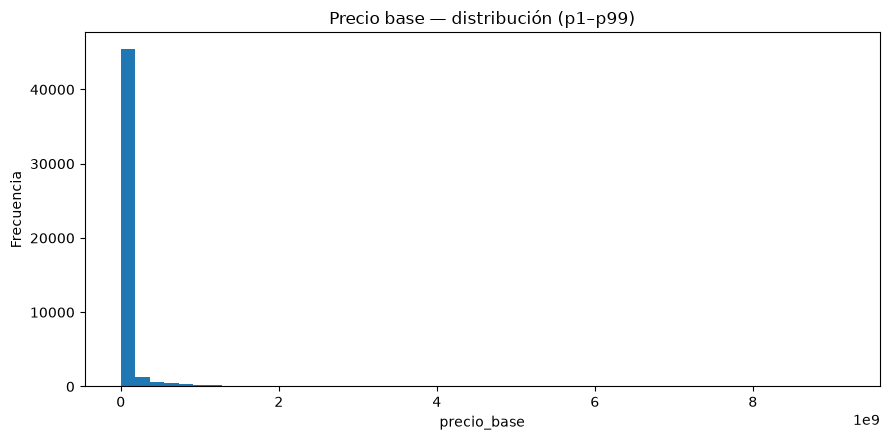

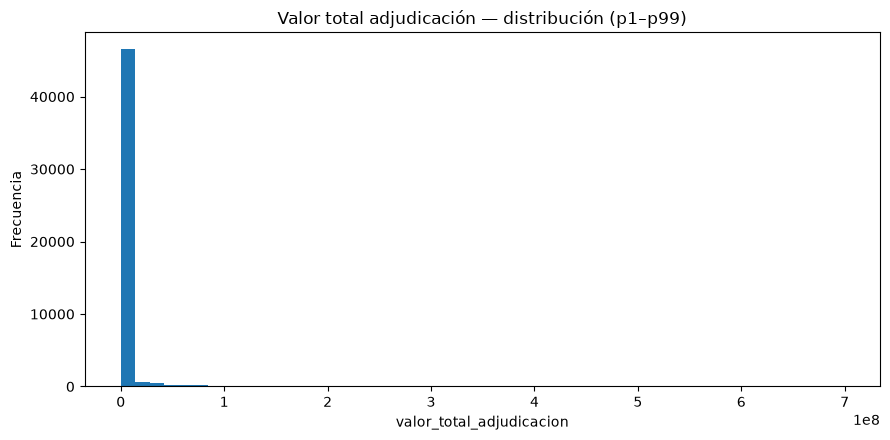

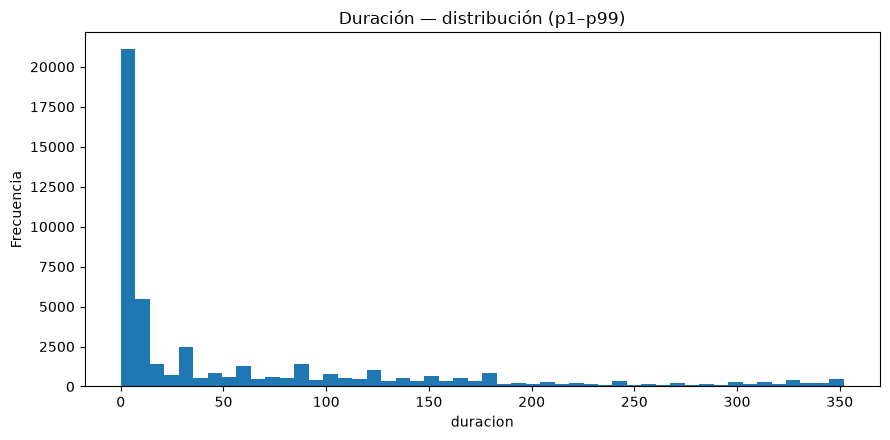

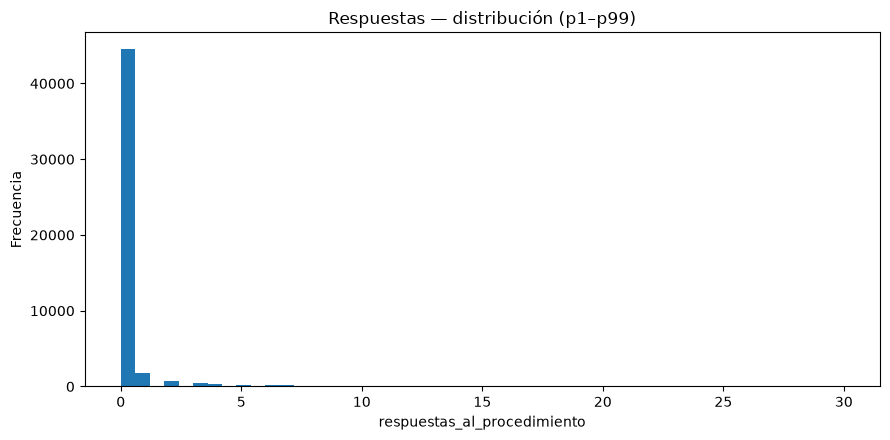

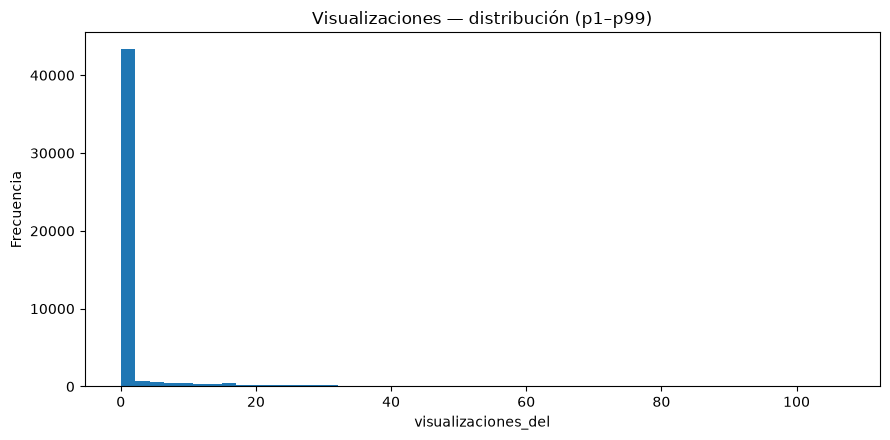

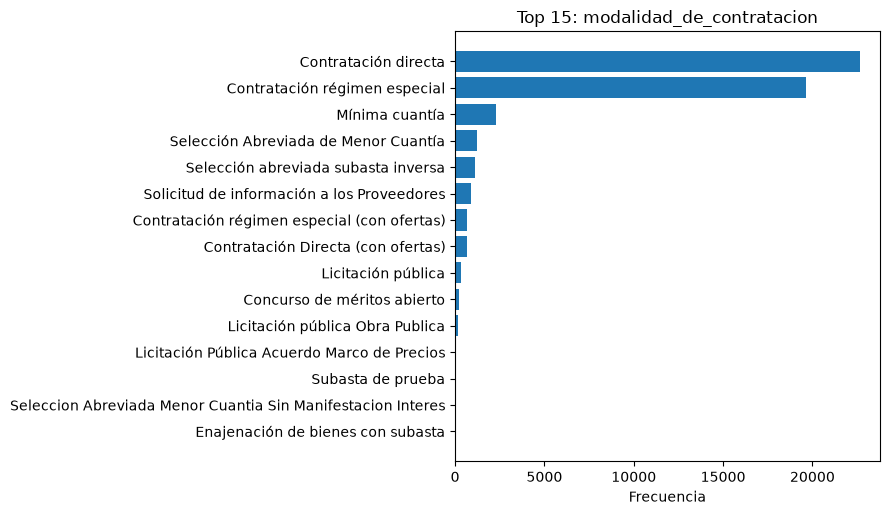

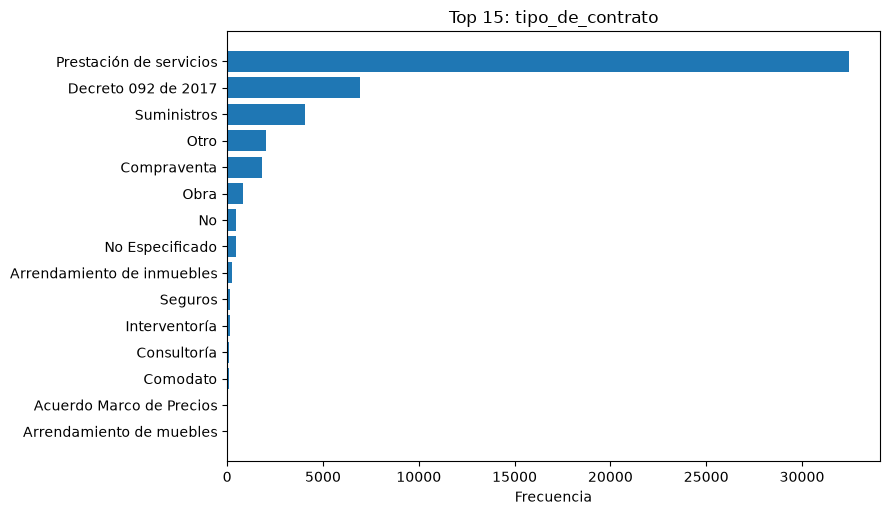

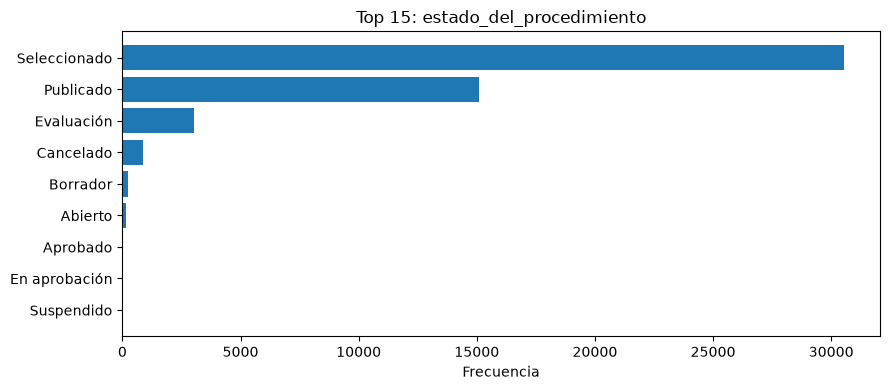

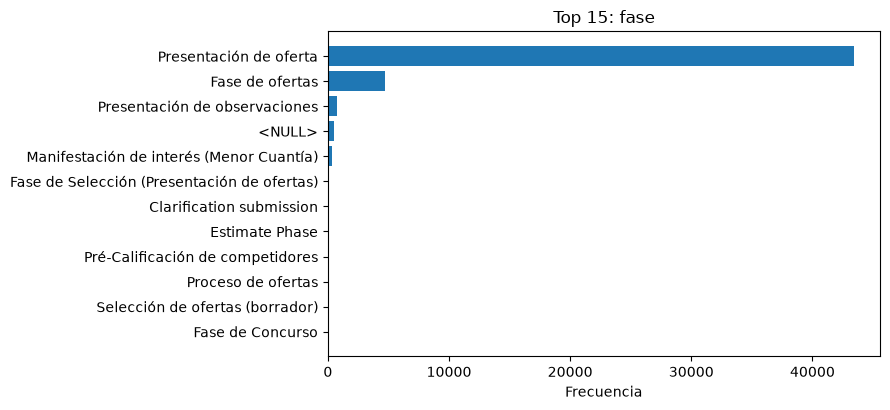

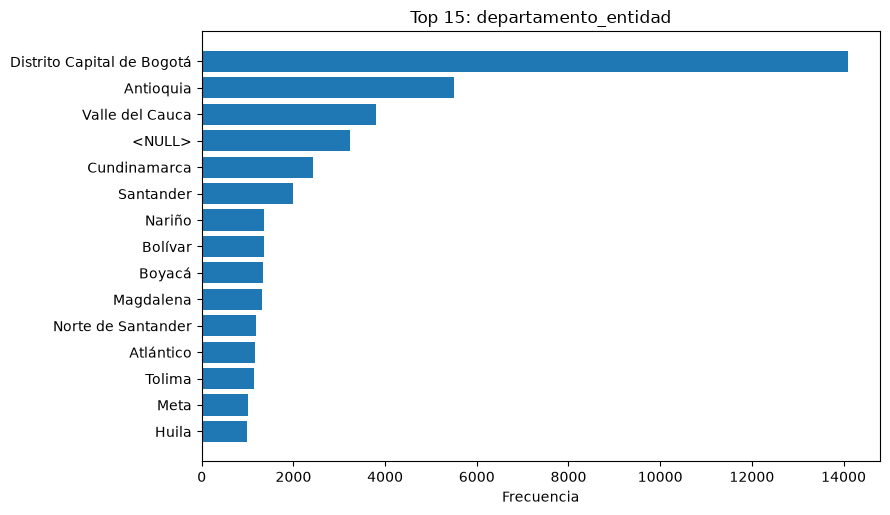

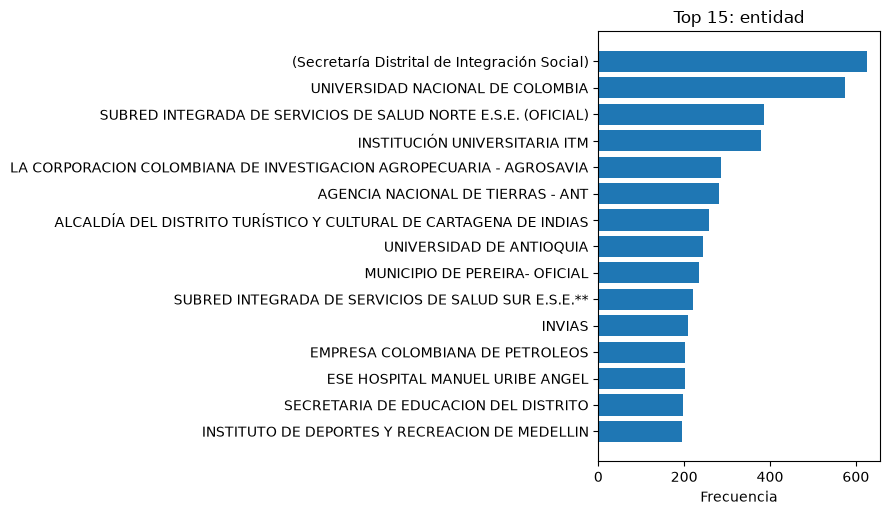

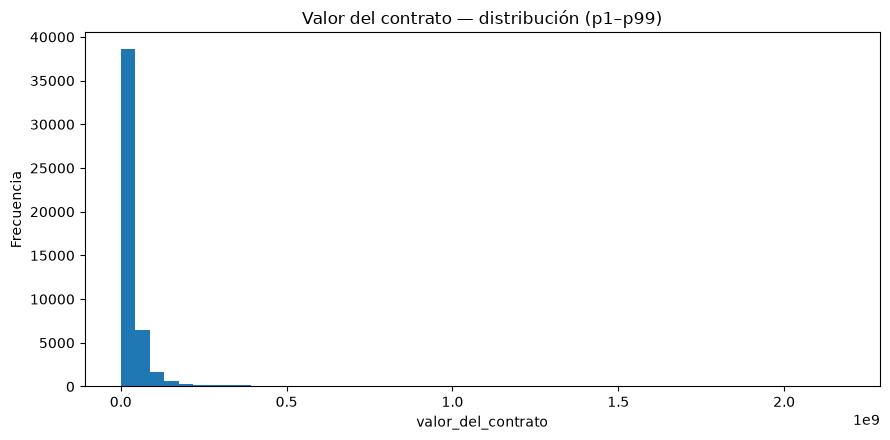

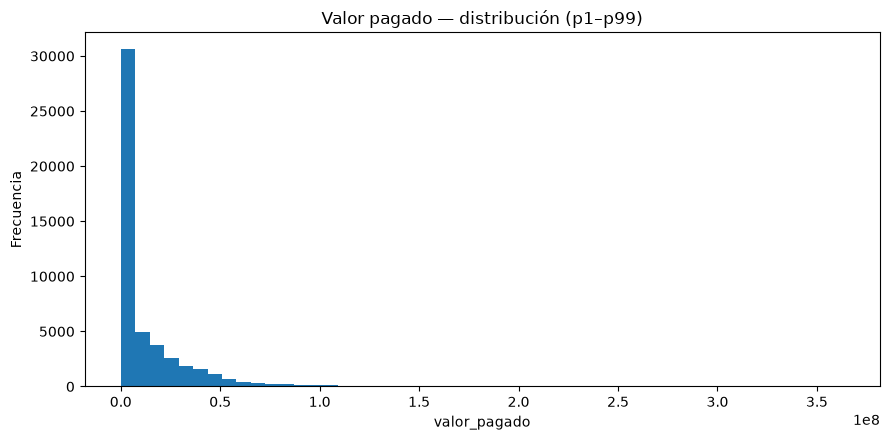

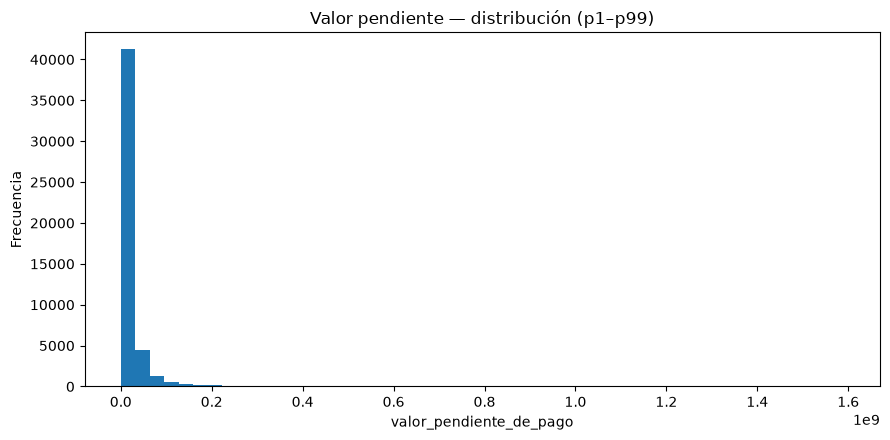

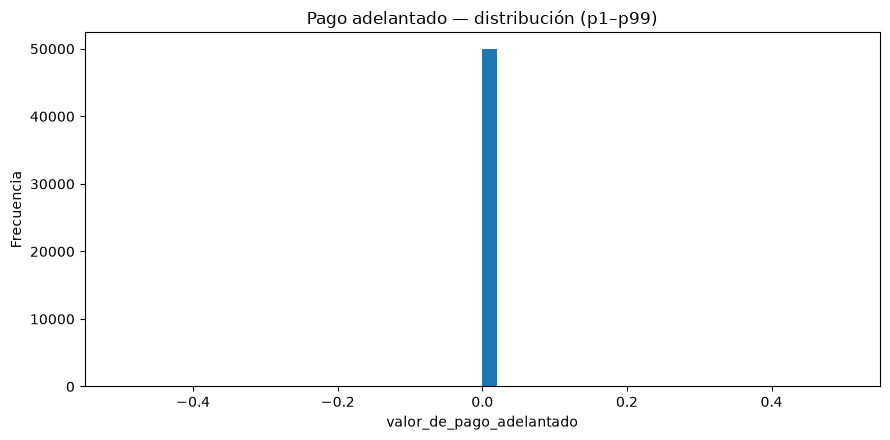

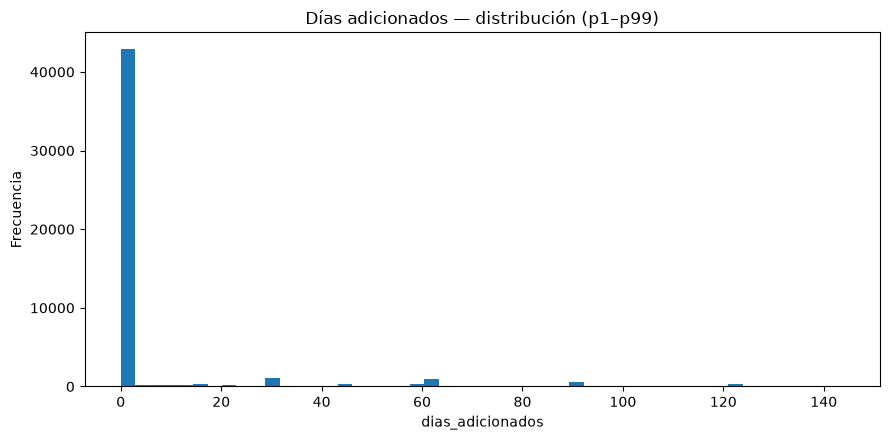

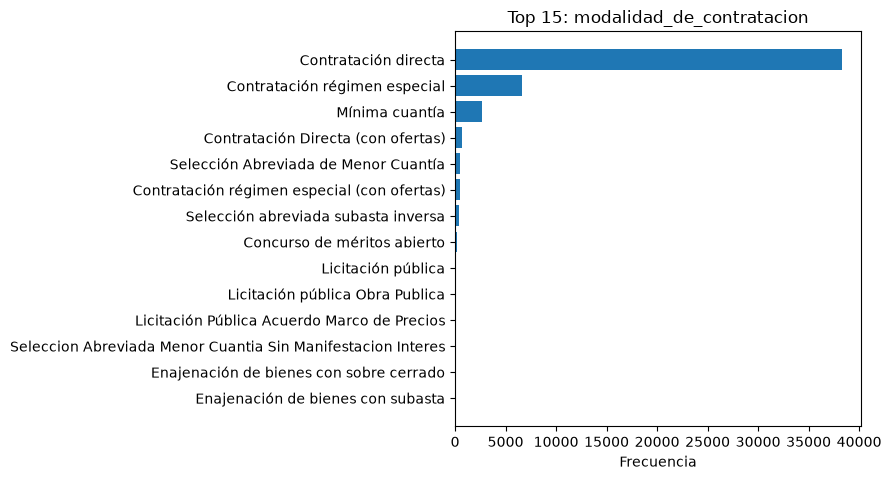

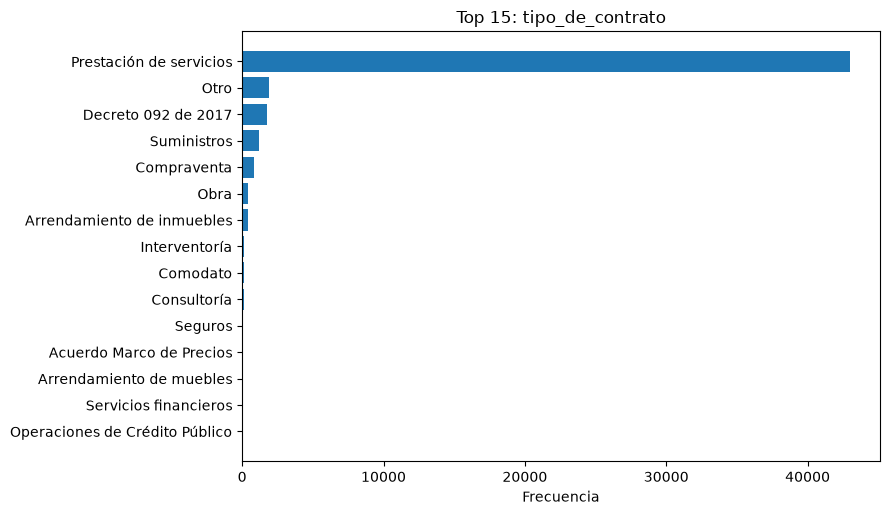

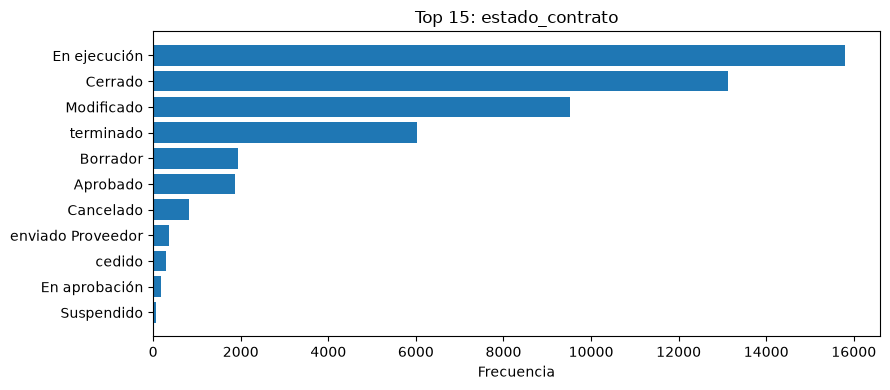

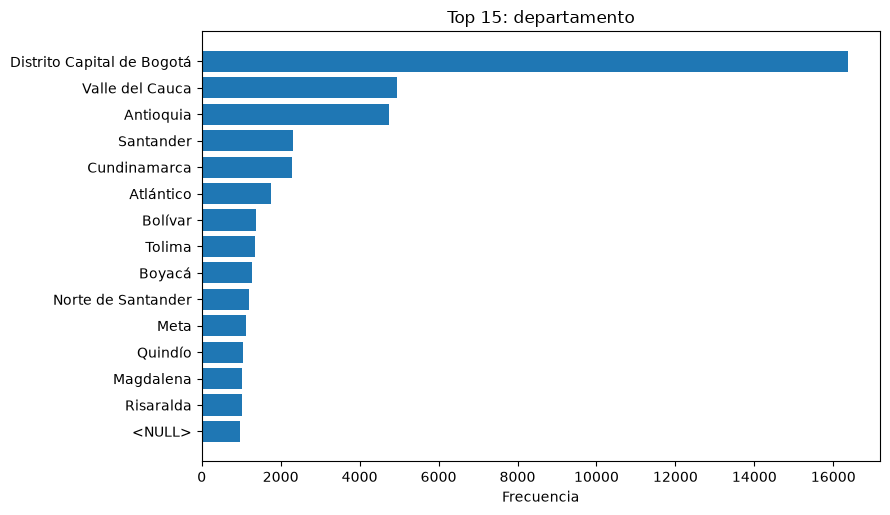

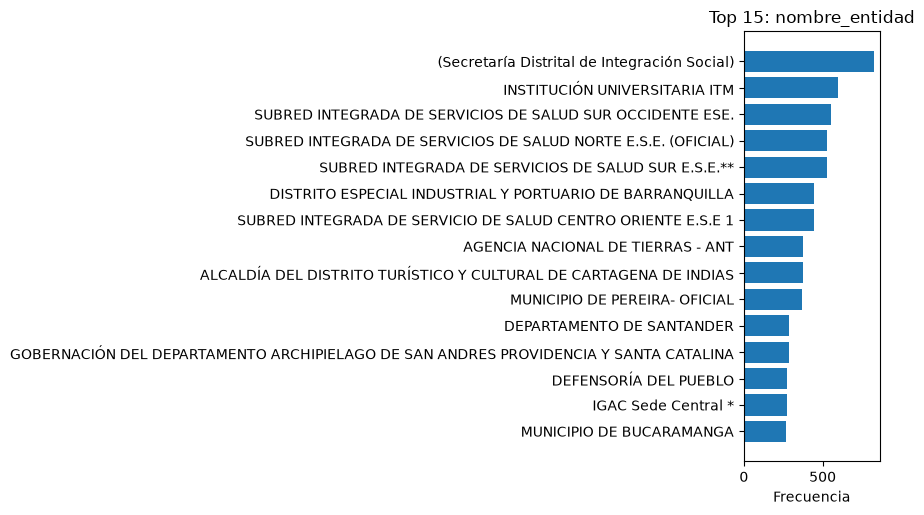

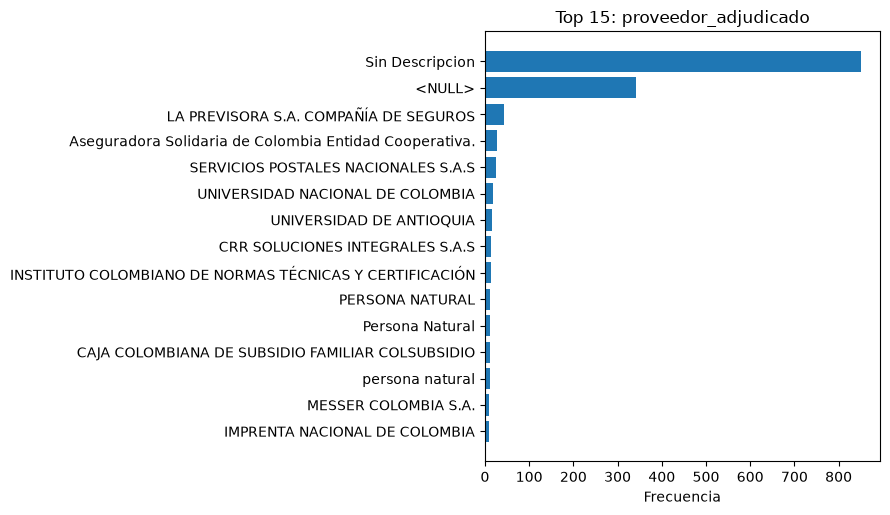

In [9]:
def resolve_col(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    cols = set(df.columns)
    for c in candidates:
        c2 = normalize_colname(c)
        if c2 in cols:
            return c2
    for candidate in candidates:
        tokens = [t for t in normalize_colname(candidate).split("_") if len(t) > 2]
        for c in df.columns:
            if tokens and all(t in c for t in tokens):
                return c
    return None

def plot_numeric_distributions(df: pd.DataFrame, candidate_groups: dict):
    for label, candidates in candidate_groups.items():
        c = resolve_col(df, candidates)
        if not c:
            continue
        x = pd.to_numeric(df[c], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
        if x.empty:
            continue
        lo, hi = x.quantile([0.01, 0.99])
        xv = x[(x >= lo) & (x <= hi)]
        plt.figure(figsize=(9, 4.5))
        plt.hist(xv, bins=50)
        plt.title(f"{label} — distribución (p1–p99)")
        plt.xlabel(c)
        plt.ylabel("Frecuencia")
        plt.tight_layout()
        plt.show()

def plot_top_categories(df: pd.DataFrame, candidates: List[str], top_n=15):
    for cand in candidates:
        c = resolve_col(df, [cand])
        if not c:
            continue
        vc = df[c].astype("string").fillna("<NULL>").value_counts().head(top_n).sort_values()
        plt.figure(figsize=(9, max(4, 0.35 * len(vc))))
        plt.barh(vc.index.astype(str), vc.values)
        plt.title(f"Top {top_n}: {c}")
        plt.xlabel("Frecuencia")
        plt.tight_layout()
        plt.show()

if procesos_eda is not None:
    plot_numeric_distributions(procesos_eda, {
        "Precio base": ["precio_base"],
        "Valor total adjudicación": ["valor_total_adjudicacion"],
        "Duración": ["duracion"],
        "Respuestas": ["respuestas_al_procedimiento"],
        "Visualizaciones": ["visualizaciones_del_procedimiento", "visualizaciones_del"],
    })
    plot_top_categories(procesos_eda, [
        "modalidad_de_contratacion", "tipo_de_contrato", "estado_del_procedimiento",
        "fase", "departamento_entidad", "entidad"
    ], TOP_N_CATEGORIES)

if contratos_eda is not None:
    plot_numeric_distributions(contratos_eda, {
        "Valor del contrato": ["valor_del_contrato"],
        "Valor pagado": ["valor_pagado"],
        "Valor pendiente": ["valor_pendiente_de_pago"],
        "Pago adelantado": ["valor_de_pago_adelantado"],
        "Días adicionados": ["dias_adicionados"],
    })
    plot_top_categories(contratos_eda, [
        "modalidad_de_contratacion", "tipo_de_contrato", "estado_contrato",
        "departamento", "nombre_entidad", "proveedor_adjudicado"
    ], TOP_N_CATEGORIES)

## 9. Correlación Pearson y Spearman

Se excluyen identificadores/códigos de la matriz numérica. Correlación no implica causalidad.

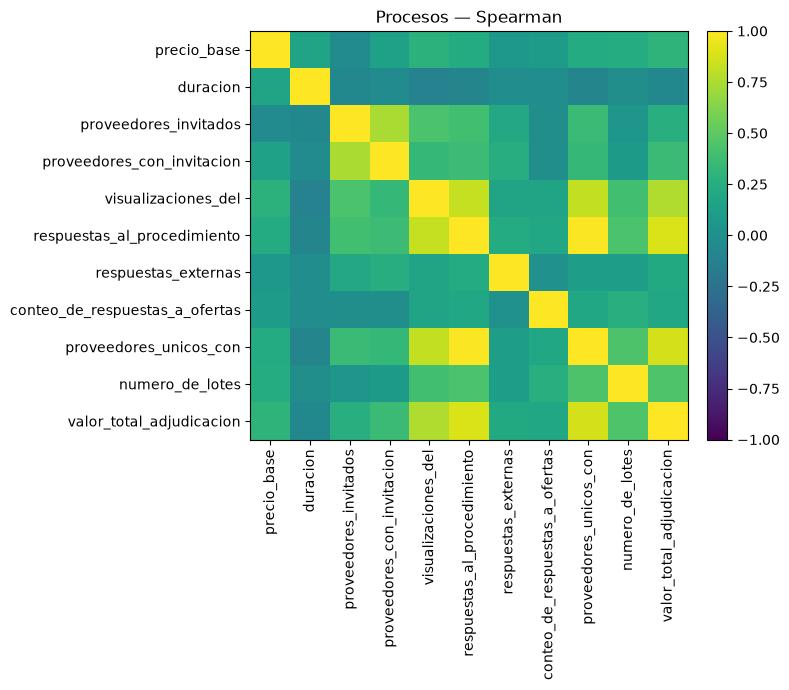

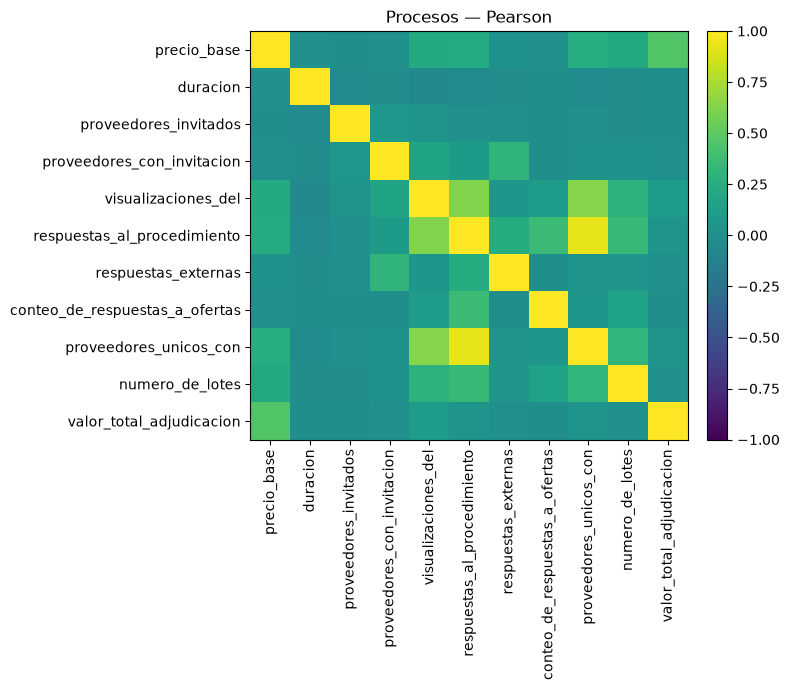

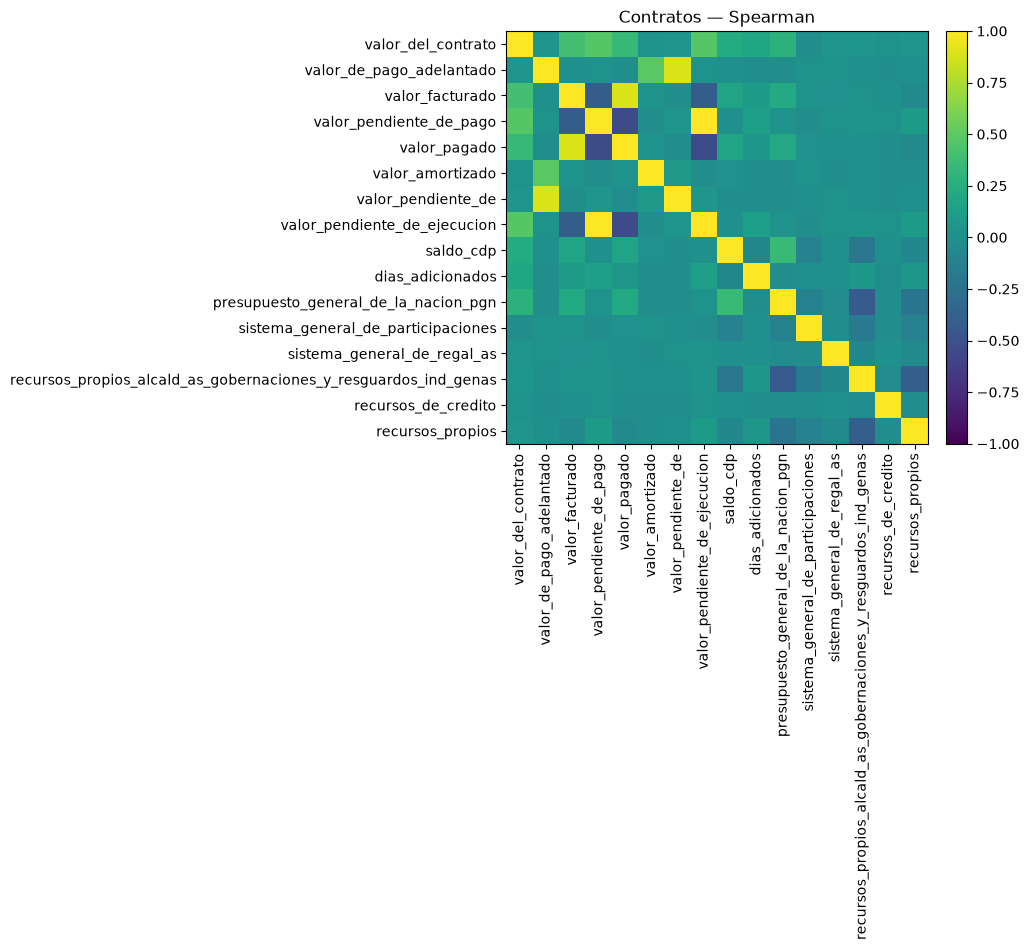

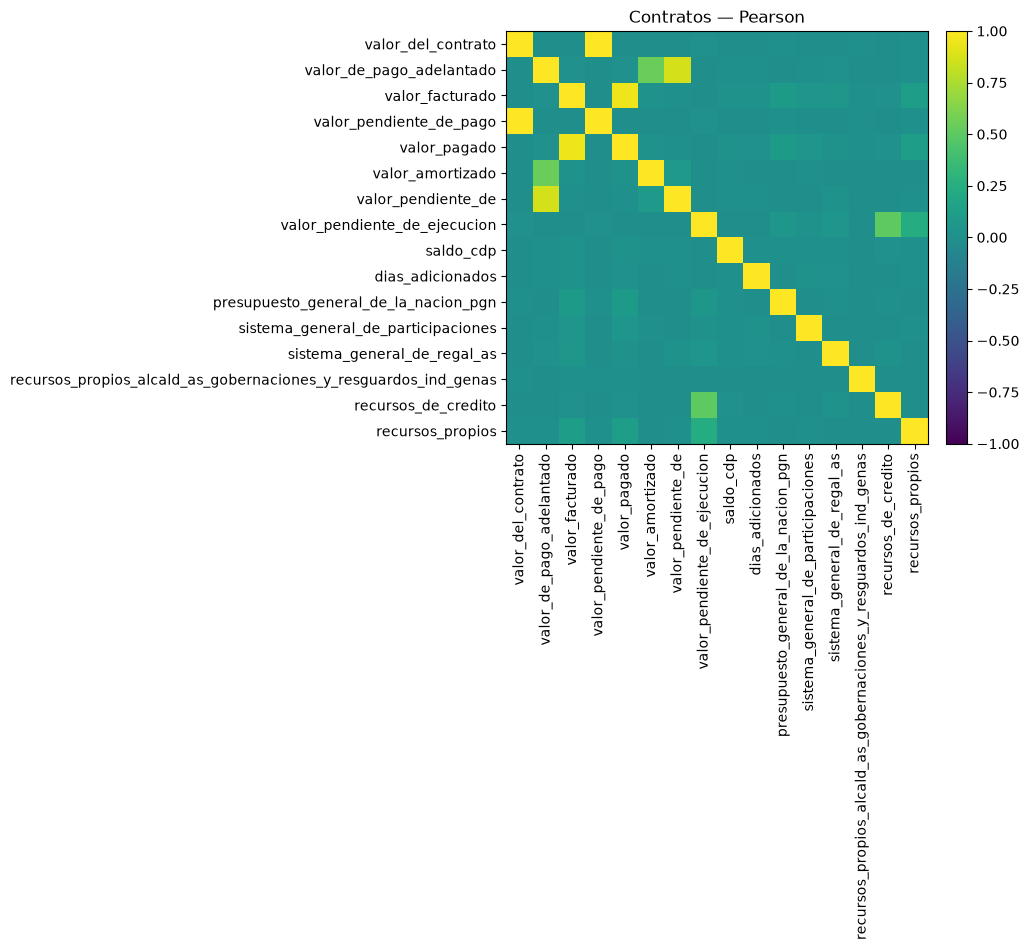

In [10]:
def usable_numeric_df(df: pd.DataFrame, min_non_null=0.20, max_cols=30) -> pd.DataFrame:
    roles = classify_columns(df).set_index("variable")["rol_inferido"]
    candidates = []
    for c in df.columns:
        if roles[c] != "numerica":
            continue
        x = pd.to_numeric(df[c], errors="coerce")
        if x.notna().mean() < min_non_null or x.nunique(dropna=True) <= 1:
            continue
        candidates.append(c)
    if len(candidates) > max_cols:
        score = {}
        for c in candidates:
            x = pd.to_numeric(df[c], errors="coerce")
            score[c] = x.notna().mean() * np.log1p(x.nunique(dropna=True))
        candidates = sorted(candidates, key=score.get, reverse=True)[:max_cols]
    return df[candidates].apply(pd.to_numeric, errors="coerce")

def plot_corr_heatmap(df: pd.DataFrame, method="spearman", title=None):
    num = usable_numeric_df(df)
    if num.shape[1] < 2:
        print("No hay suficientes variables numéricas.")
        return None
    corr = num.corr(method=method)
    fig, ax = plt.subplots(figsize=(max(8, 0.65*corr.shape[1]), max(7, 0.6*corr.shape[1])))
    im = ax.imshow(corr.values, aspect="auto", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticks(range(len(corr.columns)))
    ax.set_yticklabels(corr.columns)
    ax.set_title(title or f"Correlación {method.title()}")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
    return corr

if procesos_eda is not None:
    corr_proc_s = plot_corr_heatmap(procesos_eda, "spearman", "Procesos — Spearman")
    corr_proc_p = plot_corr_heatmap(procesos_eda, "pearson", "Procesos — Pearson")

if contratos_eda is not None:
    corr_cont_s = plot_corr_heatmap(contratos_eda, "spearman", "Contratos — Spearman")
    corr_cont_p = plot_corr_heatmap(contratos_eda, "pearson", "Contratos — Pearson")

## 10. Scatter-plots relevantes

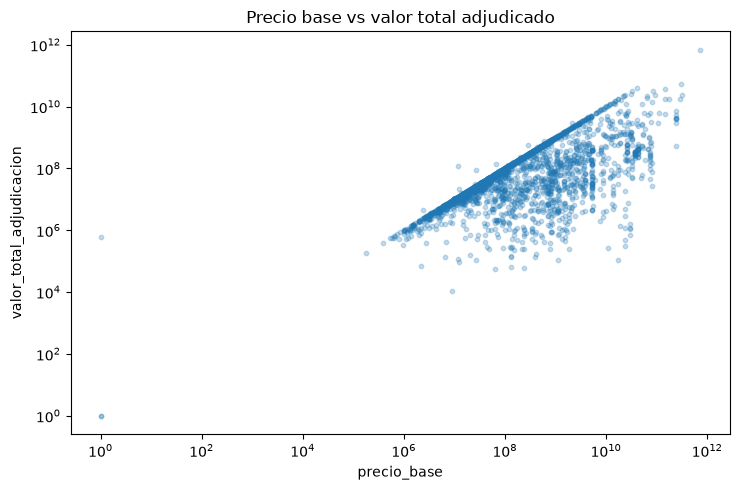

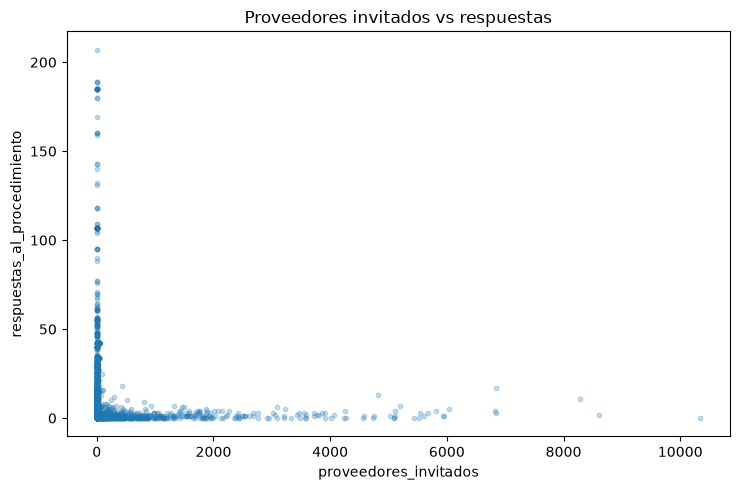

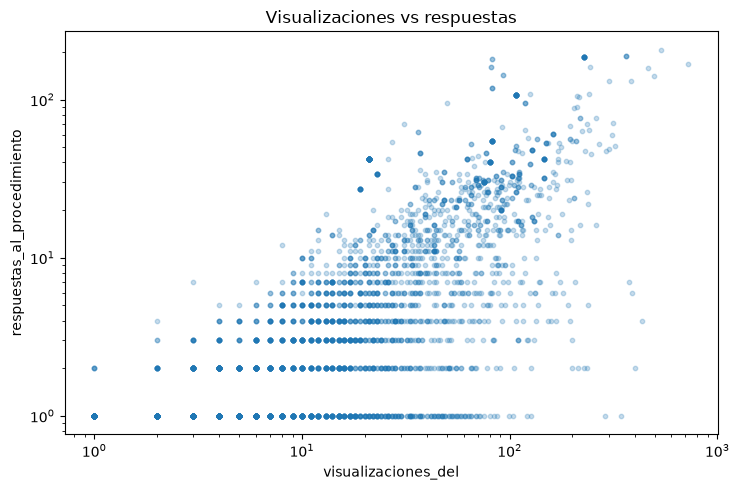

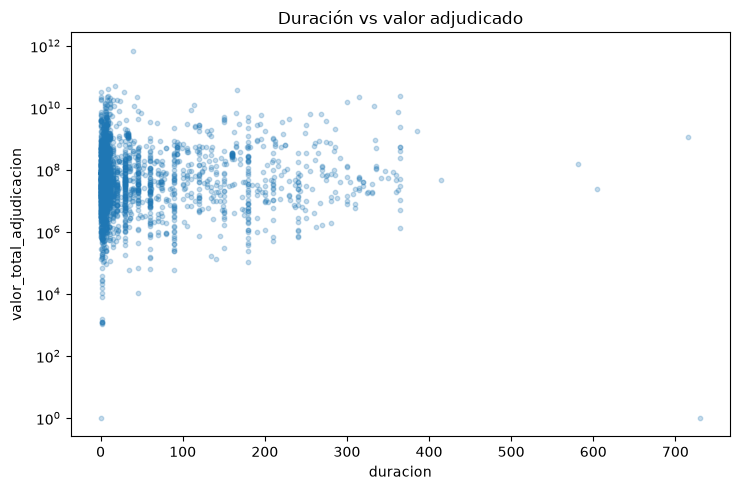

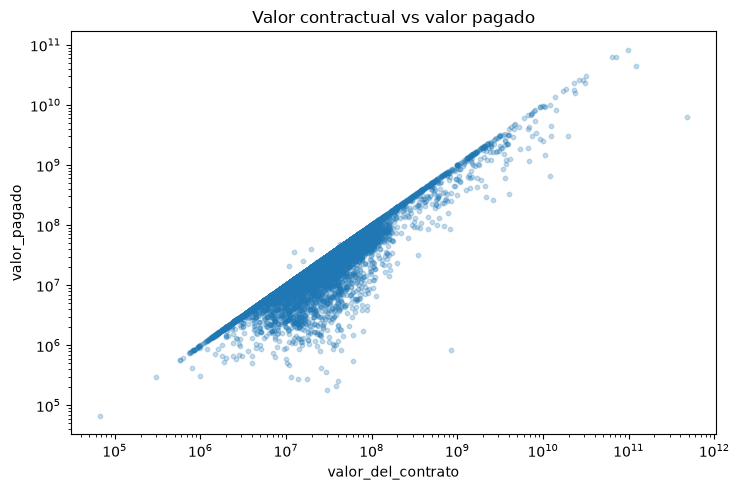

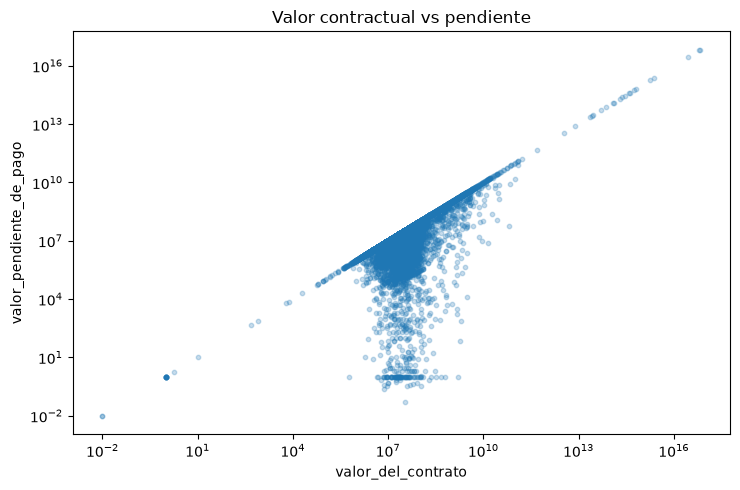

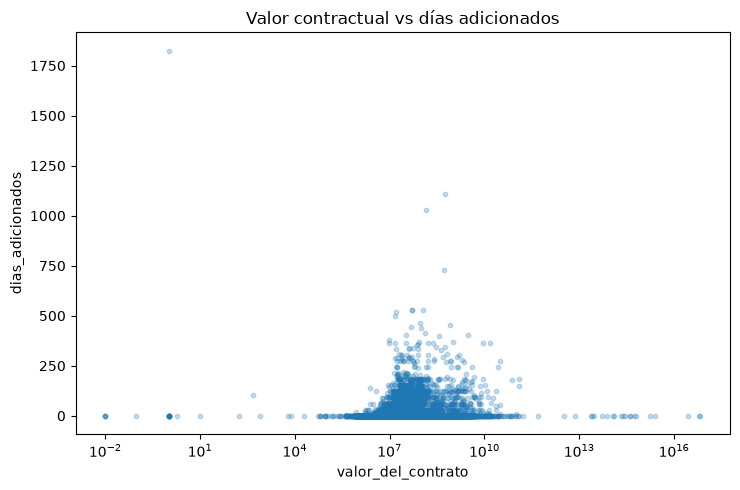

In [11]:
def scatter_safe(df, x_candidates, y_candidates, title, logx=False, logy=False, max_points=30000):
    xcol = resolve_col(df, x_candidates)
    ycol = resolve_col(df, y_candidates)
    if not xcol or not ycol:
        print(f"Saltado: {title}")
        return
    tmp = pd.DataFrame({
        "x": pd.to_numeric(df[xcol], errors="coerce"),
        "y": pd.to_numeric(df[ycol], errors="coerce")
    }).replace([np.inf, -np.inf], np.nan).dropna()
    if len(tmp) > max_points:
        tmp = tmp.sample(max_points, random_state=RANDOM_STATE)
    if logx:
        tmp = tmp[tmp["x"] > 0]
    if logy:
        tmp = tmp[tmp["y"] > 0]
    if tmp.empty:
        return
    plt.figure(figsize=(7.5, 5))
    plt.scatter(tmp["x"], tmp["y"], alpha=0.25, s=10)
    if logx:
        plt.xscale("log")
    if logy:
        plt.yscale("log")
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.title(title)
    plt.tight_layout()
    plt.show()

if procesos_eda is not None:
    scatter_safe(procesos_eda, ["precio_base"], ["valor_total_adjudicacion"],
                 "Precio base vs valor total adjudicado", logx=True, logy=True)
    scatter_safe(procesos_eda, ["proveedores_invitados"], ["respuestas_al_procedimiento"],
                 "Proveedores invitados vs respuestas")
    scatter_safe(procesos_eda, ["visualizaciones_del_procedimiento", "visualizaciones_del"],
                 ["respuestas_al_procedimiento"], "Visualizaciones vs respuestas", logx=True, logy=True)
    scatter_safe(procesos_eda, ["duracion"], ["valor_total_adjudicacion"],
                 "Duración vs valor adjudicado", logy=True)

if contratos_eda is not None:
    scatter_safe(contratos_eda, ["valor_del_contrato"], ["valor_pagado"],
                 "Valor contractual vs valor pagado", logx=True, logy=True)
    scatter_safe(contratos_eda, ["valor_del_contrato"], ["valor_pendiente_de_pago"],
                 "Valor contractual vs pendiente", logx=True, logy=True)
    scatter_safe(contratos_eda, ["valor_del_contrato"], ["dias_adicionados"],
                 "Valor contractual vs días adicionados", logx=True)

## 11. Llaves primarias candidatas

In [12]:
PROCESS_PK_CANDIDATES = ["id_del_proceso", "referencia_del_proceso", "id_adjudicacion"]
CONTRACT_PK_CANDIDATES = ["id_contrato", "referencia_del_contrato"]

def key_test(df: pd.DataFrame, candidates: List[str]) -> pd.DataFrame:
    rows = []
    n = len(df)
    for cand in candidates:
        c = resolve_col(df, [cand])
        if not c:
            rows.append({"candidata": cand, "encontrada": False})
            continue
        s = df[c]
        n_null = int(s.isna().sum())
        n_unique = s.nunique(dropna=True)
        rows.append({
            "candidata": cand, "columna": c, "encontrada": True, "n": n,
            "nulos": n_null, "n_unicos": n_unique,
            "unique_ratio": n_unique / n if n else np.nan,
            "duplicados_extra": int(s.duplicated().sum()),
            "pk_valida_en_muestra": (n_null == 0 and n_unique == n)
        })
    return pd.DataFrame(rows)

if procesos_eda is not None:
    display(key_test(procesos_eda, PROCESS_PK_CANDIDATES))

if contratos_eda is not None:
    display(key_test(contratos_eda, CONTRACT_PK_CANDIDATES))

,candidata,columna,encontrada,n,nulos,n_unicos,unique_ratio,duplicados_extra,pk_valida_en_muestra
0,id_del_proceso,id_del_proceso,True,50000,0,49258,0.98516,742,False
1,referencia_del_proceso,referencia_del_proceso,True,50000,0,47612,0.95224,2388,False
2,id_adjudicacion,id_adjudicacion,True,50000,0,3981,0.07962,46019,False


,candidata,columna,encontrada,n,nulos,n_unicos,unique_ratio,duplicados_extra,pk_valida_en_muestra
0,id_contrato,id_contrato,True,50000,0,49901,0.99802,99,False
1,referencia_del_contrato,referencia_del_contrato,True,50000,3,48333,0.96666,1666,False


## 12. Enlace sobre el universo local

Se comparan ambas hipótesis sin usar las muestras independientes para inferir huérfanos. `proceso_de_compra` comparte códigos con `id_del_portafolio`; no se asume una correspondencia uno a uno con `id_del_proceso`. El denominador de cobertura son códigos distintos no vacíos. Las filas repetidas y las relaciones múltiples impiden una unión directa sin definir el grano.

In [13]:
cross = duckdb.connect(config={"memory_limit": "2GB", "threads": 2})
cross.read_parquet(str(PROCESS_PATH)).create_view("p")
cross.read_parquet(str(CONTRACT_PATH)).create_view("c")
rows = []
for key in ["id_del_proceso", "id_del_portafolio"]:
    sql = f"""WITH pk AS (SELECT DISTINCT trim("{key}") k FROM p WHERE nullif(trim("{key}"),'') IS NOT NULL),
    fk AS (SELECT DISTINCT trim(proceso_de_compra) k FROM c WHERE nullif(trim(proceso_de_compra),'') IS NOT NULL)
    SELECT (SELECT count(*) FROM pk), (SELECT count(*) FROM fk),
    (SELECT count(*) FROM pk JOIN fk USING(k))"""
    parent, child, matches = cross.execute(sql).fetchone()
    rows.append(dict(llave_procesos=key, llave_contratos="proceso_de_compra", codigos_procesos=parent,
                     codigos_compra=child, codigos_compartidos=matches,
                     compras_sin_coincidencia=child-matches, cobertura_compras_pct=100*matches/child if child else np.nan))
fk_summary = pd.DataFrame(rows)
display(fk_summary)
display(Markdown("La coincidencia de portafolio es una relación candidata de enlace, no una PK validada. La ausencia de coincidencia puede depender de cobertura y semántica; no demuestra una irregularidad."))
cross.close()


,llave_procesos,llave_contratos,codigos_procesos,codigos_compra,codigos_compartidos,compras_sin_coincidencia,cobertura_compras_pct
0,id_del_proceso,proceso_de_compra,8770125,4196187,0,4196187,0.00000
1,id_del_portafolio,proceso_de_compra,8541424,4196187,4090407,105780,97.47914


La coincidencia de portafolio es una relación candidata de enlace, no una PK validada. La ausencia de coincidencia puede depender de cobertura y semántica; no demuestra una irregularidad.

### Otras relaciones
- NIT Entidad ↔ NIT Entidad.
- NIT proveedor adjudicado ↔ Documento Proveedor.
- Código UNSPSC ↔ catálogo UNSPSC.
- Ubicación ↔ catálogo territorial.

Deben normalizarse antes de imponer FK.

In [14]:
display(Markdown("El cruce por NIT entre muestras independientes no estima cobertura poblacional. La evidencia completa por entidad y multiplicidades se presenta al final."))

El cruce por NIT entre muestras independientes no estima cobertura poblacional. La evidencia completa por entidad y multiplicidades se presenta al final.

## 13. Red flags de auditoría

Las banderas son priorización analítica, no conclusiones jurídicas.

In [15]:
def to_num(df, candidates):
    c = resolve_col(df, candidates)
    return c, (pd.to_numeric(df[c], errors="coerce") if c else None)

def to_date(df, candidates):
    c = resolve_col(df, candidates)
    return c, (pd.to_datetime(df[c], errors="coerce") if c else None)

def audit_flags_processes(df):
    out = pd.DataFrame(index=df.index)
    _, base = to_num(df, ["precio_base"])
    _, award = to_num(df, ["valor_total_adjudicacion"])
    if base is not None and award is not None:
        out["flag_adjudicacion_sobre_precio_base"] = (base > 0) & (award > base)
        out["ratio_adjudicacion_precio_base"] = np.where(base > 0, award/base, np.nan)
    _, resp = to_num(df, ["respuestas_al_procedimiento", "conteo_de_respuestas_a_ofertas"])
    if resp is not None:
        out["flag_cero_respuestas"] = resp.eq(0)
        out["flag_unica_respuesta"] = resp.eq(1)
    _, pub = to_date(df, ["fecha_de_publicacion_del_proceso", "fecha_de_publicacion_del"])
    _, adj = to_date(df, ["fecha_adjudicacion"])
    if pub is not None and adj is not None:
        out["flag_adjudicacion_antes_publicacion"] = adj < pub
    return out

def audit_flags_contracts(df):
    out = pd.DataFrame(index=df.index)
    _, val = to_num(df, ["valor_del_contrato"])
    _, pag = to_num(df, ["valor_pagado"])
    _, pen = to_num(df, ["valor_pendiente_de_pago"])
    if val is not None:
        out["flag_valor_contrato_negativo"] = val < 0
    if pag is not None:
        out["flag_valor_pagado_negativo"] = pag < 0
    if pen is not None:
        out["flag_pendiente_negativo"] = pen < 0
    if val is not None and pag is not None:
        out["flag_pagado_supera_contrato"] = pag > val
        out["ratio_pagado_contrato"] = np.where(val > 0, pag/val, np.nan)
    _, ini = to_date(df, ["fecha_de_inicio_del_contrato", "fecha_de_inicio_de_ejecucion"])
    _, fin = to_date(df, ["fecha_de_fin_del_contrato", "fecha_fin_de_ejecucion"])
    _, firma = to_date(df, ["fecha_de_firma"])
    if ini is not None and fin is not None:
        out["flag_fin_antes_inicio"] = fin < ini
        out["duracion_calculada_dias"] = (fin - ini).dt.days
    if firma is not None and fin is not None:
        out["flag_firma_despues_fin"] = firma > fin
    return out

if procesos_eda is not None:
    flags_proc = audit_flags_processes(procesos_eda)
    display(flags_proc.select_dtypes(include="bool").mean().sort_values(ascending=False).rename("tasa").to_frame())

if contratos_eda is not None:
    flags_cont = audit_flags_contracts(contratos_eda)
    display(flags_cont.select_dtypes(include="bool").mean().sort_values(ascending=False).rename("tasa").to_frame())

,tasa
flag_cero_respuestas,0.89044
flag_unica_respuesta,0.03674
flag_adjudicacion_sobre_precio_base,0.00098
flag_adjudicacion_antes_publicacion,0.00000


,tasa
flag_firma_despues_fin,0.00334
flag_pendiente_negativo,0.00062
flag_pagado_supera_contrato,0.00062
flag_fin_antes_inicio,0.00016
flag_valor_pagado_negativo,0.00000
flag_valor_contrato_negativo,0.00000


## 14. Concentración por proveedor (HHI)

El HHI siguiente es descriptivo de la muestra y de valores registrados por fila, afectados por repeticiones y extremos. No representa concentración del mercado nacional. Entidades sin valor positivo no tienen HHI definido.

In [16]:
def supplier_concentration_contracts(df):
    ent = resolve_col(df, ["nit_entidad", "nombre_entidad"])
    prov = resolve_col(df, ["documento_proveedor", "proveedor_adjudicado"])
    valc = resolve_col(df, ["valor_del_contrato"])
    if not all([ent, prov, valc]):
        return None, None
    tmp = df[[ent, prov, valc]].copy()
    tmp[valc] = pd.to_numeric(tmp[valc], errors="coerce")
    tmp = tmp.dropna(subset=[ent, prov, valc])
    tmp = tmp[tmp[valc] >= 0]
    ep = tmp.groupby([ent, prov], as_index=False)[valc].sum()
    totals = ep.groupby(ent)[valc].transform("sum")
    ep["share"] = np.where(totals > 0, ep[valc] / totals, np.nan)
    ep = ep[totals > 0].copy()
    hhi = (
        ep.assign(share2=ep["share"]**2)
          .groupby(ent, as_index=False)
          .agg(hhi=("share2", "sum"), proveedores=(prov, "nunique"), valor_total=(valc, "sum"))
          .sort_values("hhi", ascending=False)
    )
    return ep, hhi

if contratos_eda is not None:
    ep, hhi = supplier_concentration_contracts(contratos_eda)
    if hhi is not None:
        display(hhi.head(30))

,nit_entidad,hhi,proveedores,valor_total
2150,901995820,1.0,1,1.050000e+07
7,800006095,1.0,1,4.087622e+07
2136,9017979675,1.0,1,6.428400e+07
2139,901829766,1.0,1,1.553382e+08
2143,901844405,1.0,1,7.500000e+06
591,808003500,1.0,1,4.200000e+06
589,808002121,1.0,1,4.480000e+06
586,808001195,1.0,1,2.342006e+07
584,808000716,1.0,1,2.505000e+06
583,808000033,1.0,1,9.180000e+06


## 15. Modelo conceptual

```text
ENTIDAD PÚBLICA
   │
   ├────< PROCESO DE CONTRATACIÓN >────┐
   │                │                   │
   │                v                   │
   │           ADJUDICACIÓN             │
   │                │                   │
   │                v                   │
   │             PROVEEDOR              │
   │                                    │
   └────────< CONTRATO >────────────────┘
                  │
                  ├── ejecución
                  ├── pagos
                  ├── adiciones
                  ├── obligaciones
                  └── fuentes de recursos

PROCESO ──< PROCESO_CATEGORÍA >── UNSPSC
ENTIDAD / PROVEEDOR ──> UBICACIÓN
```

Granularidades:
- proceso;
- adjudicación/proveedor/lote;
- contrato;
- contrato × fuente de recursos;
- proceso/contrato × UNSPSC.

## 16. Modelo lógico normalizado (3NF)

**entidad**
- `entidad_sk` PK
- `nit_entidad` UNIQUE
- nombre, orden, sector, rama, centralización, ubicación

**proveedor**
- `proveedor_sk` PK
- tipo documento + documento normalizado UNIQUE
- nombre, grupo, pyme, representante legal

**proceso**
- `id_proceso` PK
- `entidad_sk` FK
- referencia, modalidad, tipo, fase, estado
- precio base, duración, fechas, respuestas

**adjudicacion**
- PK propia / `id_adjudicacion`
- `id_proceso` FK
- `proveedor_sk` FK
- fecha y valor adjudicado

**contrato**
- `id_contrato` PK
- `id_proceso` FK
- `entidad_sk` FK
- `proveedor_sk` FK
- estado, fechas, valores, pagos, adiciones

**proceso_unspsc**
- PK compuesta (`id_proceso`, `codigo_unspsc`)

**contrato_fuente_recurso**
- PK compuesta (`id_contrato`, `fuente_recurso`)

## 17. Normalización

### 1NF
- separar listas de categorías UNSPSC;
- convertir fuentes de recursos múltiples en filas.

### 2NF
- atributos de catálogo no deben depender de una parte de una PK compuesta.

### 3NF
- datos de entidad dependen del NIT;
- datos de proveedor dependen del documento;
- geografía depende de una dimensión territorial.

**No se normaliza la capa RAW.** Se conserva íntegra para auditoría y reproducibilidad.

## 18. Arquitectura Big Data: Bronze → Silver → Gold

**Bronze**
- copia inmutable de origen;
- Parquet;
- partición por fecha de extracción;
- hash y timestamp.

**Silver**
- tipificación;
- documentos normalizados;
- fechas;
- 3NF;
- integridad referencial;
- deduplicación controlada;
- reglas de calidad.

**Gold**
- modelo dimensional:
  - `fact_proceso`
  - `fact_adjudicacion`
  - `fact_contrato`
  - `fact_pago`
  - `dim_entidad`
  - `dim_proveedor`
  - `dim_fecha`
  - `dim_ubicacion`
  - `dim_unspsc`
  - `dim_modalidad`
  - `dim_tipo_contrato`

Silver optimiza integridad; Gold optimiza consulta analítica.

## 19. Modelo físico — PostgreSQL

In [17]:
DDL_POSTGRES = '''
CREATE SCHEMA IF NOT EXISTS raw;
CREATE SCHEMA IF NOT EXISTS silver;
CREATE SCHEMA IF NOT EXISTS gold;

CREATE TABLE IF NOT EXISTS silver.entidad (
    entidad_sk BIGSERIAL PRIMARY KEY,
    nit_entidad VARCHAR(30) NOT NULL UNIQUE,
    nombre_entidad TEXT,
    orden_entidad VARCHAR(100),
    sector VARCHAR(200),
    rama VARCHAR(100),
    entidad_centralizada VARCHAR(50),
    departamento VARCHAR(150),
    ciudad VARCHAR(150)
);

CREATE TABLE IF NOT EXISTS silver.proveedor (
    proveedor_sk BIGSERIAL PRIMARY KEY,
    tipo_documento VARCHAR(100),
    documento_normalizado VARCHAR(40) NOT NULL,
    nombre_proveedor TEXT,
    es_grupo BOOLEAN,
    es_pyme BOOLEAN,
    UNIQUE (tipo_documento, documento_normalizado)
);

CREATE TABLE IF NOT EXISTS silver.proceso (
    id_proceso VARCHAR(100) PRIMARY KEY,
    referencia_proceso TEXT,
    entidad_sk BIGINT NOT NULL REFERENCES silver.entidad(entidad_sk),
    modalidad TEXT,
    justificacion_modalidad TEXT,
    tipo_contrato TEXT,
    subtipo_contrato TEXT,
    fase TEXT,
    estado TEXT,
    precio_base NUMERIC(24,2),
    duracion NUMERIC,
    unidad_duracion VARCHAR(50),
    fecha_publicacion TIMESTAMP,
    fecha_ultima_publicacion TIMESTAMP,
    fecha_adjudicacion TIMESTAMP,
    url_proceso TEXT
);

CREATE INDEX IF NOT EXISTS idx_proceso_entidad ON silver.proceso(entidad_sk);
CREATE INDEX IF NOT EXISTS idx_proceso_fecha_pub ON silver.proceso(fecha_publicacion);

CREATE TABLE IF NOT EXISTS silver.adjudicacion (
    adjudicacion_sk BIGSERIAL PRIMARY KEY,
    id_adjudicacion VARCHAR(120),
    id_proceso VARCHAR(100) NOT NULL REFERENCES silver.proceso(id_proceso),
    proveedor_sk BIGINT REFERENCES silver.proveedor(proveedor_sk),
    fecha_adjudicacion TIMESTAMP,
    valor_adjudicado NUMERIC(24,2)
);

CREATE UNIQUE INDEX IF NOT EXISTS uq_adjudicacion_id
ON silver.adjudicacion(id_adjudicacion)
WHERE id_adjudicacion IS NOT NULL;

CREATE TABLE IF NOT EXISTS silver.contrato (
    id_contrato VARCHAR(120) PRIMARY KEY,
    id_proceso VARCHAR(100) REFERENCES silver.proceso(id_proceso),
    entidad_sk BIGINT NOT NULL REFERENCES silver.entidad(entidad_sk),
    proveedor_sk BIGINT REFERENCES silver.proveedor(proveedor_sk),
    referencia_contrato TEXT,
    estado_contrato TEXT,
    tipo_contrato TEXT,
    modalidad TEXT,
    fecha_firma TIMESTAMP,
    fecha_inicio TIMESTAMP,
    fecha_fin TIMESTAMP,
    fecha_inicio_ejecucion TIMESTAMP,
    fecha_fin_ejecucion TIMESTAMP,
    valor_contrato NUMERIC(24,2),
    valor_pagado NUMERIC(24,2),
    valor_pendiente_pago NUMERIC(24,2),
    dias_adicionados INTEGER,
    url_proceso TEXT
);

CREATE INDEX IF NOT EXISTS idx_contrato_proceso ON silver.contrato(id_proceso);
CREATE INDEX IF NOT EXISTS idx_contrato_entidad ON silver.contrato(entidad_sk);
CREATE INDEX IF NOT EXISTS idx_contrato_proveedor ON silver.contrato(proveedor_sk);

CREATE TABLE IF NOT EXISTS silver.fuente_recurso (
    fuente_recurso_sk SMALLSERIAL PRIMARY KEY,
    nombre_fuente TEXT UNIQUE NOT NULL
);

CREATE TABLE IF NOT EXISTS silver.contrato_fuente_recurso (
    id_contrato VARCHAR(120) REFERENCES silver.contrato(id_contrato),
    fuente_recurso_sk SMALLINT REFERENCES silver.fuente_recurso(fuente_recurso_sk),
    valor_fuente NUMERIC(24,2),
    PRIMARY KEY (id_contrato, fuente_recurso_sk)
);
'''
print(DDL_POSTGRES)


CREATE SCHEMA IF NOT EXISTS raw;
CREATE SCHEMA IF NOT EXISTS silver;
CREATE SCHEMA IF NOT EXISTS gold;

CREATE TABLE IF NOT EXISTS silver.entidad (
    entidad_sk BIGSERIAL PRIMARY KEY,
    nit_entidad VARCHAR(30) NOT NULL UNIQUE,
    nombre_entidad TEXT,
    orden_entidad VARCHAR(100),
    sector VARCHAR(200),
    rama VARCHAR(100),
    entidad_centralizada VARCHAR(50),
    departamento VARCHAR(150),
    ciudad VARCHAR(150)
);

CREATE TABLE IF NOT EXISTS silver.proveedor (
    proveedor_sk BIGSERIAL PRIMARY KEY,
    tipo_documento VARCHAR(100),
    documento_normalizado VARCHAR(40) NOT NULL,
    nombre_proveedor TEXT,
    es_grupo BOOLEAN,
    es_pyme BOOLEAN,
    UNIQUE (tipo_documento, documento_normalizado)
);

CREATE TABLE IF NOT EXISTS silver.proceso (
    id_proceso VARCHAR(100) PRIMARY KEY,
    referencia_proceso TEXT,
    entidad_sk BIGINT NOT NULL REFERENCES silver.entidad(entidad_sk),
    modalidad TEXT,
    justificacion_modalidad TEXT,
    tipo_contrato TEXT,
    subtipo_

## 20. Diseño físico para volumen

- RAW en Parquet, no JSON como formato analítico final.
- Particionar por año/mes de publicación o firma.
- No particionar por IDs de alta cardinalidad.
- Índices: PK, FK proceso, NIT entidad, documento proveedor y fechas de filtro.
- Ingestión incremental con `extraction_ts`, `source_dataset_id`, hash y vigencia del registro.
- Diferenciar nuevos registros, actualizaciones y bajas lógicas.

## 21. Controles de calidad en producción

| Regla | Severidad sugerida |
|---|---|
| PK nula | crítica |
| PK duplicada | crítica |
| FK contrato→proceso huérfana | alta |
| valor pagado > valor contrato | alta |
| fecha fin < fecha inicio | alta |
| NIT entidad vacío | alta |
| documento proveedor vacío | media/alta |
| valores negativos | alta |
| aumento súbito de nulos | alta |
| cambio inesperado de esquema | crítica |

Cada control debe guardar evidencia: dataset, ID, campo, valor, timestamp y versión de regla.

## 22. Indicadores por stakeholder

### Contraloría
- valor y número de contratos por entidad/proveedor;
- HHI;
- repetición entidad–proveedor;
- cero/una respuesta;
- huérfanos;
- duplicados;
- inconsistencias monetarias/temporales;
- adjudicación vs precio base;
- adiciones;
- outliers por UNSPSC, territorio y modalidad.

### Entidad
- tiempo publicación→adjudicación;
- respuestas;
- tasa de adjudicación;
- ejecución/pagos;
- calidad;
- benchmarking.

### Proveedor
- compradores por UNSPSC;
- valor mediano/p25/p75;
- calendario;
- modalidades;
- territorios;
- competencia;
- duración/pago.

In [18]:
def stakeholder_tables(procesos_df=None, contratos_df=None):
    outputs = {}
    if procesos_df is not None:
        ent = resolve_col(procesos_df, ["entidad"])
        mod = resolve_col(procesos_df, ["modalidad_de_contratacion"])
        val = resolve_col(procesos_df, ["valor_total_adjudicacion", "precio_base"])
        if ent and val:
            tmp = procesos_df.copy()
            tmp[val] = pd.to_numeric(tmp[val], errors="coerce")
            outputs["procesos_por_entidad"] = (
                tmp.groupby(ent, dropna=False)
                   .agg(filas_procesos_muestra=(ent, "size"), valor=(val, "sum"), mediana=(val, "median"))
                   .sort_values("valor", ascending=False).head(30).reset_index()
            )
        if mod:
            outputs["procesos_por_modalidad"] = (
                procesos_df[mod].astype("string").fillna("<NULL>")
                .value_counts().head(30).rename_axis(mod).reset_index(name="n")
            )

    if contratos_df is not None:
        ent = resolve_col(contratos_df, ["nombre_entidad", "nit_entidad"])
        prov = resolve_col(contratos_df, ["proveedor_adjudicado", "documento_proveedor"])
        val = resolve_col(contratos_df, ["valor_del_contrato"])
        if ent and prov and val:
            tmp = contratos_df[[ent, prov, val]].copy()
            tmp[val] = pd.to_numeric(tmp[val], errors="coerce")
            outputs["top_proveedores"] = (
                tmp.groupby(prov, dropna=False)
                   .agg(filas_contratos_muestra=(prov, "size"), valor_contratado=(val, "sum"), entidades=(ent, "nunique"))
                   .sort_values("valor_contratado", ascending=False).head(30).reset_index()
            )
    return outputs

tabs = stakeholder_tables(procesos_eda, contratos_eda)
for name, table in tabs.items():
    print("\n", name.upper())
    display(table)


 PROCESOS_POR_ENTIDAD


,entidad,filas_procesos_muestra,valor,mediana
0,SENA DIRECCION GENERAL,10,7.088910e+11,0.0
1,DISTRITO ESPECIAL DE CIENCIA TECNOLOGIA E INNOVACION DE MEDELLIN,131,1.988892e+11,0.0
2,INVIAS,208,1.605629e+11,0.0
3,SECRETARIA DE EDUCACION DEL DISTRITO,197,1.249201e+11,0.0
4,SECRETARIA DE EDUCACION DE CALI,75,1.003017e+11,0.0
5,UARIV-UNIDAD PARA LA ATENCION Y REPARACION INTEGRAL A LAS VICTIMAS,109,7.697633e+10,0.0
6,UNP,87,7.383000e+10,0.0
7,DISTRITO ESPECIAL INDUSTRIAL Y PORTUARIO DE BARRANQUILLA,99,7.352422e+10,0.0
8,"AGENCIA DISTRITAL PARA LA EDUCACIÓN SUPERIOR, LA CIENCIA Y LA TECNOLOGÍA, ATENEA",32,6.947649e+10,966781334.5
9,INSTITUTO DE DESARROLLO URBANO,96,6.856135e+10,0.0



 PROCESOS_POR_MODALIDAD


,modalidad_de_contratacion,n
0,Contratación directa,22650
1,Contratación régimen especial,19653
2,Mínima cuantía,2289
3,Selección Abreviada de Menor Cuantía,1238
4,Selección abreviada subasta inversa,1113
5,Solicitud de información a los Proveedores,910
6,Contratación régimen especial (con ofertas),679
7,Contratación Directa (con ofertas),641
8,Licitación pública,336
9,Concurso de méritos abierto,213



 TOP_PROVEEDORES


,proveedor_adjudicado,filas_contratos_muestra,valor_contratado,entidades
0,ORACLE COLOMBIA LTDA,4,6.757699e+16,4
1,C MEDICAL SAS,1,6.148960e+16,1
2,Fundación Hogar San Francisco De Asis,1,2.775090e+16,1
3,guillermo león arboleda gómez,1,6.966685e+15,1
4,CINDY KATHERINE GONZALEZ CRUZ,1,2.464110e+15,1
5,DIANA ISABEL PINEDA ZULETA,1,1.796815e+15,1
6,Sin Descripcion,851,9.663739e+14,498
7,Yesid Antonio Barón Santos,1,8.922169e+14,1
8,GUSTAVO ADOLFO VELASQUEZ GOMEZ,1,8.292022e+14,1
9,Andres Camilo Enriquez Insuasty,1,6.250000e+14,1


## 23. Exportación de resultados CSV

Los nombres distinguen muestras y universo local.

In [19]:
# Exportación abierta, sin dependencia de Excel.
exportables = {"perfil_procesos_muestra": perfil_procesos, "perfil_contratos_muestra": perfil_contratos,
    "calidad_procesos_muestra": quality_profile(procesos_eda),
    "calidad_contratos_muestra": quality_profile(contratos_eda), "integridad_universo_local": fk_summary,
    **{name + "_muestra": table for name, table in tabs.items()}}
for name, table in exportables.items():
    table.to_csv(OUTPUT_DIR / f"{name}.csv", index=False, encoding="utf-8-sig")
print("Tablas exportadas:", len(exportables))


Tablas exportadas: 8


## 24. Checklist antes de producción

- [ ] congelar versión de ambos datasets;
- [ ] registrar timestamp y conteo;
- [ ] comparar esquema real vs metadata;
- [ ] confirmar PK de procesos;
- [ ] confirmar PK de contratos;
- [ ] confirmar FK `proceso_de_compra → id_del_proceso`;
- [ ] medir huérfanos sobre universo completo;
- [ ] normalizar documentos sin destruir el dato fuente;
- [ ] separar UNSPSC multivaluado;
- [ ] separar fuentes de recursos;
- [ ] implementar Bronze/Silver/Gold;
- [ ] crear histórico de calidad;
- [ ] automatizar pruebas;
- [ ] validar red flags con expediente oficial.

**Estado:** configurado y ejecutable con el entorno local; datos de septiembre. Las hipótesis de PK y FK del diseño original requieren revisar las observaciones repetidas y el enlace por portafolio antes de implementar restricciones.

## 25. Conclusión

Las dos bases deben verse como una cadena:

**Entidad → Proceso → Adjudicación → Proveedor → Contrato → Ejecución/Pagos**

`p6dx-8zbt` explica el proceso de selección y `jbjy-vk9h` el resultado contractual y su ejecución. El objetivo no es pegar dos tablas anchas, sino construir una arquitectura trazable que permita control fiscal, gestión institucional y análisis de mercado.

## 26. Resultados completos e interpretación sustentada

Las siguientes tablas y conclusiones provienen de la ejecución completa del **26 de septiembre de 2026**. Se reutilizan como evidencia histórica, no se presentan como estadísticas recalculadas hoy. Se contrasta el conteo del Parquet con el registrado en cobertura. Los gráficos y perfiles anteriores sí se ejecutan en esta sesión sobre una nueva muestra reproducible.

Los totales monetarios por fila no deben llamarse gasto consolidado: hay identificadores repetidos y extremos importantes. El DDL anterior es una propuesta; las restricciones UNIQUE sobre documentos y los enlaces directos proceso–contrato necesitan reglas de identidad y granularidad antes de su uso.

In [20]:
for base in ["procesos", "contratos"]:
    folder = EVIDENCE / base / "completo_local"
    coverage = json.loads((folder / "cobertura.json").read_text(encoding="utf-8"))
    assert coverage["filas_leidas"] == full_context[base]["n"], "El corte cambió: recalcular evidencia completa"
    display(Markdown(f"### {base.title()}: evidencia del corte completo"))
    display(pd.DataFrame([coverage]).T)
    for filename in ["llaves.csv", "duplicados.csv", "alertas.csv", "estadisticos_numericos.csv"]:
        display(Markdown(f"**{filename} — universo local**"))
        display(pd.read_csv(folder / filename))
    display(Markdown((folder / "resumen.md").read_text(encoding="utf-8")))
display(Markdown("### Cruce previo por entidad y cardinalidad"))
display(Markdown((EVIDENCE / "cruce_bases/resumen.md").read_text(encoding="utf-8")))


### Procesos: evidencia del corte completo

,0
base,procesos
dataset,p6dx-8zbt
nombre,SECOP II - Procesos de Contratación
alcance,completo_local
filas_leidas,9205394
archivos_leidos,369
archivos_disponibles,369
filas_declaradas_inicio,9205394
offset_descarga,9205394
descarga_marcada_completa,True


**llaves.csv — universo local**

,columna,nulos,distintos,repeticiones_no_nulas,candidata_primaria
0,id_del_proceso,0,8770125,435269,False
1,id_del_portafolio,0,8541424,663970,False
2,id_adjudicacion,0,551629,8653765,False
3,codigo_entidad,0,12344,9193050,False
4,nit_entidad,0,11576,9193818,False
5,codigoproveedor,8235273,158587,811534,False
6,id_del_proceso + id_adjudicacion,0,8797089,408305,False


**duplicados.csv — universo local**

...

**estadisticos_numericos.csv — universo local**

,n,media,mediana,moda,desviacion,minimo,q1,q3,maximo,asimetria,columna,cv,limite_iqr_inferior,limite_iqr_superior,atipicos_iqr,pct_atipicos_validos
0,6066673.0,6.055357e+14,19999998.0,0.0,6.145811e+17,0.000000e+00,9866667.0,40357801.0,8.818042e+20,1193.032938,valor_del_contrato,1014.937804,-35870034.0,86094502.0,606227,9.992742
1,6066673.0,1.053857e+09,0.0,0.0,2.594391e+12,0.000000e+00,0.0,0.0,6.390144e+15,2463.061702,valor_de_pago_adelantado,2461.806223,0.0,0.0,6140,0.101209
2,6066673.0,5.474570e+07,3822000.0,0.0,1.778732e+09,0.000000e+00,0.0,21705320.0,1.088472e+12,248.100596,valor_facturado,32.490816,-32557980.0,54263300.0,448310,7.389718
3,6066673.0,6.584502e+12,7500000.0,0.0,3.235153e+15,-3.338183e+10,0.0,22092000.0,4.371683e+18,964.041555,valor_pendiente_de_pago,491.328417,-33138000.0,55230000.0,578007,9.527578
4,6066673.0,4.616185e+07,0.0,0.0,1.628691e+09,0.000000e+00,0.0,18186667.0,1.088472e+12,272.704246,valor_pagado,35.282187,-27280000.5,45466667.5,518473,8.546249
5,6066673.0,5.579283e+04,0.0,0.0,1.128777e+07,0.000000e+00,0.0,0.0,1.024449e+10,524.032095,valor_amortizado,202.315854,0.0,0.0,1347,0.022203
6,6066673.0,1.053801e+09,0.0,0.0,2.594391e+12,-3.299754e+09,0.0,0.0,6.390144e+15,2463.061702,valor_pendiente_de,2461.936562,0.0,0.0,5296,0.087297
7,6066673.0,1.294569e+12,7500000.0,0.0,1.129098e+15,-3.338183e+10,0.0,22063500.0,2.218385e+18,1536.053251,valor_pendiente_de_ejecucion,872.180015,-33095250.0,55158750.0,577277,9.515545
8,6066673.0,3.193149e+10,8549100.0,0.0,4.910158e+13,0.000000e+00,0.0,65646167.0,1.111111e+17,2043.272772,saldo_cdp,1537.716718,-98469250.5,164115417.5,1134531,18.701041
9,6066673.0,1.091232e+09,0.0,0.0,2.314560e+11,0.000000e+00,0.0,0.0,2.304000e+14,975.756411,saldo_vigencia,212.105217,0.0,0.0,91813,1.513400


# Resultados EDA: Contratos Electrónicos

- Alcance: **completo_local**. Filas leídas: **6,066,673**; columnas: **85**.
- Fuente: `jbjy-vk9h`. Descarga marcada completa: **False**.
- Diferencia respecto al total anunciado al iniciar la descarga: **-57** filas. No demuestra por sí sola cobertura íntegra de una fuente cambiante.
- Duplicados exactos originales: **53**. Se conservaron para hacer explícita la unidad de observación; las agregaciones son por fila.
- Llaves candidatas sin nulos y únicas en este corte: **ninguna entre las evaluadas**.
- Mayor ausencia tras tipado: `descripcion_documentos_tipo`, **99.60%**.
- `valor_del_contrato`: mediana **19,999,998.00**, media **605,535,697,020,691.38**; atípicos IQR: **606,227**. Un atípico no equivale a un error.
- Máximo registrado en ese campo: **881,804,150,601,557,082,112.00**. La diferencia entre media y mediana exige revisar los extremos; `mayores_valores.csv` conserva los 20 mayores en texto decimal para su auditoría. No se interpretan automáticamente como valores económicamente plausibles.

## Lectura por propósitos
La modalidad con más filas es **Contratación directa**, con **4,655,482** (**76.74%** del corte).

**Proveedores:** 6,066,673 filas tienen código de proveedor; los diez códigos con más filas concentran **2.73%** de ese subconjunto. Los códigos no se equiparan automáticamente con personas jurídicas únicas ni con grupos empresariales.

**Procesos desiertos:** la base de contratos no representa los procedimientos que nunca generaron contrato. Este propósito requiere consultar Procesos y validar el enlace, no inferirlo de la ausencia de contratos.

**Control fiscal — condiciones para revisión:** valor_negativo: 0; pago_supera_valor: 3,279; fin_antes_inicio: 772; pares_pago_validos: 5,883,230; mediana_fraccion_pagada: 0.000.

## Interpretación y límites
Las tablas de entidades y modalidades describen volumen y valores registrados. La ubicación corresponde a la entidad compradora, no necesariamente al lugar de ejecución. Los años inicial y final pueden ser parciales. Los ID y NIT se conservan como texto y se excluyen de las correlaciones numéricas.

Las alertas son condiciones para revisión, no prueba de irregularidad. No adjudicado o cero respuestas no significa proceso desierto: consultar estados explícitos y su contexto. Los valores monetarios se leen con el decimal original del JSON; no se eliminan puntos ni signos. Los totales están expresados en las unidades de origen; en Contratos, los metadatos monetarios indican COP.

Los estadísticos y cardinalidades son exactos sobre todas las filas seleccionadas. Correlaciones, histogramas y dispersión usan muestra reservoir con semilla 2026 y hasta 50.000 filas; valores ausentes se excluyen por pares. V de Cramér es descriptiva y sin corrección de sesgo. Las correlaciones no establecen causalidad. No se imputan ausencias, ni se eliminan extremos, duplicados o columnas vacías.

Consultar `calidad_diccionario.csv`, `alertas.csv`, `llaves.csv`, `muestreo.json`, `inventario_archivos.csv` y `bitacora_rendimiento.csv` para evidencia y trazabilidad.


### Cruce previo por entidad y cardinalidad

# Cruce entre Procesos y Contratos

Se contrastaron `id_del_proceso` e `id_del_portafolio` con `proceso_de_compra` mediante igualdad de texto tras recortar espacios. Ver `solapamiento_llaves.csv` para cobertura en ambas direcciones y multiplicidad. La coincidencia debe interpretarse junto con las descripciones de los metadatos. No se impuso una relación uno a uno.

El mayor solapamiento fue `id_del_portafolio` con `proceso_de_compra`: **4,090,407** códigos compartidos, equivalentes a **97.48%** de los códigos de compra distintos de Contratos y **47.89%** de los valores distintos del campo de Procesos. Hay multiplicidad en ambos lados; un enlace directo por fila puede inflar conteos y sumas. El cruce `id_del_proceso` ↔ `proceso_de_compra` tuvo **0** coincidencias.

El cruce por `codigo_entidad` agrega cada base antes de unirla para evitar multiplicar registros. Hay 6,247 entidades presentes en ambas bases. Correlación entre conteos de filas por entidad: Pearson=0.8047; Spearman=0.6410. Es una asociación de volumen institucional, no una tasa de éxito de procesos ni una relación causal.

Se conservaron los registros de cada fuente y los ID originales. No deben sumarse precios base y valores contractuales como si fueran magnitudes independientes. La descarga de Contratos está marcada incompleta, y las fechas de actualización de ambas fuentes difieren. Este cruce describe la intersección de los archivos locales y no garantiza una cohorte temporal común.


## 27. Conclusiones y decisiones

- **Procesos:** las 9.205.394 filas representan observaciones y contienen 8.770.125 IDs de proceso distintos. Las repeticiones impiden declarar ese ID como PK de la tabla de observaciones. Revisar primero granularidad, adjudicaciones y versiones.
- **Contratos:** 6.066.673 filas y 4.711.814 IDs distintos. La descarga está marcada incompleta y difiere en 57 filas del total anunciado al inicio; no se extrapolan estas cifras a todo SECOP II.
- **Enlace:** el ID de proceso no coincide con el código de compra contractual. El portafolio comparte 4.090.407 códigos con Contratos (97,48% de códigos de compra distintos), pero requiere tratar multiplicidades. No unir filas y sumar valores sin resolverlas.
- **Control:** las 3.279 observaciones con pago mayor al valor contractual y las 772 con fin anterior al inicio son prioridades de revisión documental. No prueban irregularidad y no necesariamente son contratos distintos.
- **Comprador:** estudiar concurrencia por modalidad, estado y proceso único; cero respuestas o no adjudicación no equivalen automáticamente a proceso desierto.
- **Proveedor:** usar medianas y segmentación por modalidad, entidad y objeto. Evitar dimensionar el mercado sumando valores con extremos sin revisión.
- **Modelo:** conservar la tabla de observaciones originales, separar entidades de negocio y registrar reglas explícitas de resolución. No eliminar duplicados de ID ni escoger arbitrariamente la última fila.

**Siguiente trabajo sustantivo:** validar expedientes extremos, resolver observaciones repetidas y completar/verificar la descarga si se exige cobertura íntegra. Estas acciones no se simulan en este notebook.


In [21]:
import hashlib
from datetime import datetime, timezone
manifest = {"ejecucion_utc": datetime.now(timezone.utc).isoformat(), "python": sys.executable,
            "semilla": RANDOM_STATE, "filas_muestra": EDA_SAMPLE_ROWS, "fuentes": {}}
for name, context in full_context.items():
    source = context["files"][0]
    manifest["fuentes"][name] = {"archivo": str(source), "bytes": source.stat().st_size,
        "mtime_ns": source.stat().st_mtime_ns, "filas": context["n"]}
    context["engine"].close()
(OUTPUT_DIR / "ejecucion_auditoria.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
print("Análisis finalizado y manifiesto guardado.")


Análisis finalizado y manifiesto guardado.
